# Contributions EDA

In [2]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
cand_summ_22 = pd.read_parquet('./datasets/cand_summ_22.parquet', engine="fastparquet")
cand_summ_24 = pd.read_parquet('./datasets/cand_summ_24.parquet', engine="fastparquet")

comm_summ_22 = pd.read_parquet('./datasets/comm_summ_22.parquet', engine="fastparquet")
comm_summ_24 = pd.read_parquet('./datasets/comm_summ_24.parquet', engine="fastparquet")

cc_ie_22 = pd.read_parquet('./datasets/cc_ie_22.parquet', engine="fastparquet")
cc_ie_24 = pd.read_parquet('./datasets/cc_ie_24.parquet', engine="fastparquet")

In [4]:
house_22_results= pd.read_csv('./raw_data/federalelections2022-house.csv',encoding='latin1')
senate_22_results = pd.read_csv('./raw_data/federalelections2022-senate.csv',encoding='latin1')

### Candidates Only
Only keep rows directly associated with a candidate id 

In [8]:
len(cc_ie_22)

751519

In [9]:
cc_ie_22 = cc_ie_22.dropna(subset='CAND_ID')

#### But, Can I count on your support
Are these tranaction in support or opposition to a candidate.
https://www.fec.gov/campaign-finance-data/transaction-type-code-descriptions/

In [10]:
support_codes = {"24E", "24F", "24C", "24H", "24K" ,"24P","24R", "24Z"}
oppose_codes = {"24A", "24N"}

cc_ie_22 = cc_ie_22.copy()
cc_ie_22["support_oppose_flag"] = "N"

cc_ie_22.loc[cc_ie_22["TRANSACTION_TP"].isin(support_codes), "support_oppose_flag"] = "S"

cc_ie_22.loc[cc_ie_22["TRANSACTION_TP"].isin(oppose_codes), "support_oppose_flag"] = "O"

In [11]:
print(len(cc_ie_22[cc_ie_22['support_oppose_flag'] == "N"]))
print(cc_ie_22[cc_ie_22['support_oppose_flag'] == "N"]['TRANSACTION_TP'].unique())
#cc_ie_22[cc_ie_22['support_oppose_flag'] == "N"]

0
[]


Before a correction these was only 23 rows labeled as N, all of which were labeled 24R. THis is the listing for 24R on the FEC website:
"24R	Election recount disbursement"
*For now I fill assume all of these to be in support

#### What the hell is a 24k?
24k - Contribution made to nonaffiliated committee, but why are there so many and what does it mean when they are associated with a candidates

Text(0.5, 1.0, 'Transaction Type')

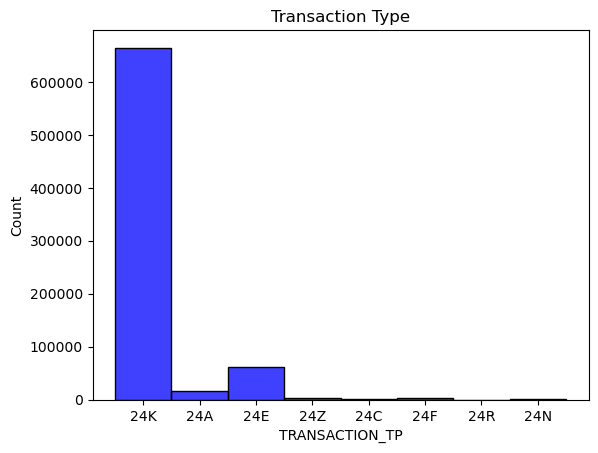

In [12]:
sns.histplot(data=cc_ie_22, x='TRANSACTION_TP', color='blue')
plt.title('Transaction Type')

In [13]:
cc_ie_22[cc_ie_22['TRANSACTION_TP']=='24K'].sample(5)

,CMTE_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,STATE,...,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,CAND_ID,TRAN_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,support_oppose_flag
13472,C00010868,N,M6,P2022,202106189449474537,24K,CCM,GARRET GRAVES FOR CONGRESS,BATON ROUGE,LA,...,2021-05-10,2500.0,C00558486,H4LA06153,B2613DB2535F74FC88D4,1520913,None,None,4062320211309669281,S
272771,C00694323,A,MY,P2020,202112209472166771,24K,CCM,PERDUE FOR SENATE,ATLANTA,GA,...,2021-01-25,35.0,C00547570,S4GA11285,AB6F31EA3B71E43CD878,1552533,None,None,4012620221394583974,S
184195,C00694323,A,MY,P2020,202112209472102725,24K,CCM,GEORGIANS FOR KELLY LOEFFLER,ATLANTA,GA,...,2021-01-15,25.0,C00729608,S0GA00526,A403C260B41974A5783A,1552533,None,None,4012620221391363004,S
359740,C00573261,A,M9,P2022,202209209528709002,24K,CCM,MAXWELL ALEJANDRO FROST FOR CONGRESS,ORLANDO,FL,...,2022-08-08,3000.0,C00786822,H2FL10259,500132511,1631536,None,None,4093020221587033410,S
264771,C00694323,A,MY,P2020,202112209472153633,24K,CCM,CATHY MCMORRIS RODGERS FOR CONGRESS,SPOKANE,WA,...,2021-01-12,5.0,C00390476,H4WA05077,A9EB52BBDE7F44325B7B,1552533,None,None,4012620221394037113,S


In [14]:
cand_names = cand_summ_22[['Cand_Id','Cand_Name']].copy()
comm_names = comm_summ_22[['CMTE_ID','CMTE_NM']].copy()
sample =  cc_ie_22[cc_ie_22['TRANSACTION_TP']=='24K'].sample(7)

pd.merge(comm_names, pd.merge(cand_names, sample[['CAND_ID','CMTE_ID','OTHER_ID','NAME']], left_on='Cand_Id', right_on='CAND_ID'), on='CMTE_ID')

,CMTE_ID,CMTE_NM,Cand_Id,Cand_Name,CAND_ID,OTHER_ID,NAME
0,C00466813,HUMANE SOCIETY LEGISLATIVE FUND POLITICAL ACTI...,H2CA06259,"HUFFMAN, JARED",H2CA06259,C00536680,HUFFMAN FOR CONGRESS
1,C00694323,WINRED,H8IA02043,"MILLER-MEEKS, MARIANNETTE JANE",H8IA02043,C00558825,MILLER-MEEKS FOR CONGRESS
2,C00694323,WINRED,S2PA00638,"OZ, MEHMET DR",S2PA00638,C00795930,DOCTOR OZ FOR SENATE


#### Conclusion: I misinterpted what was meant by 'nonaffliated' (legally not pol) but still found somethign cool

### What's this whole amendment business?

Indicates if the report being filed is new (N), an amendment (A) to a previous report or a termination (T) report.

A committee that wishes to close down its operations can file a termination report when it meets these criteria:

It no longer receives (or intends to receive) contributions; and
It no longer makes (or intends to make) expenditures.
A termination report may be filed anytime and may be combined with a regularly scheduled report. For example, a quarterly report may also serve as a termination report if the filer checks the “Termination Report” box.

In [15]:
cc_ie_22[cc_ie_22['AMNDT_IND'] == 'A'].head(2)

,CMTE_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,STATE,...,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,CAND_ID,TRAN_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,support_oppose_flag
32,C00760025,A,TER,G2020,202101079398285521,24A,PAC,MUSLIMS OF UNITED STATES OF AMERICA PAC,LAKEWOOD,CO,...,2021-01-04,29.0,H0VA01235,H0VA01235,SE.4323,1486017,None,None,4011120212068262407,O
612,C00455733,A,M2,P2022,202102119427674409,24K,CCM,BRENDA LAWRENCE FOR CONGRESS,SOUTHFIELD,MI,...,2021-01-13,1000.0,C00552588,H2MI14111,12960166,1499620,None,DIRECT CONTRIBUTION,4022620211189794740,S


In [16]:
#cc_ie_22[cc_ie_22['AMNDT_IND'] == 'A'] #.columns
cc_ie_22[cc_ie_22['TRANSACTION_TP'] == '24A'] #.columns
#cc_ie_22[cc_ie_22['TRAN_ID'] == '12960186']
#comm_summ_22[comm_summ_22['CMTE_ID']=='C00760025']

,CMTE_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,STATE,...,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,CAND_ID,TRAN_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,support_oppose_flag
8,C00760454,N,30R,R2021,202101299413959554,24A,ORG,"FIREARMS POLICY COALITION, INC.",SACRAMENTO,CA,...,2020-12-16,171.0,S8GA00180,S8GA00180,PDTE3,1493602,X,None,4020320212140454338,O
9,C00760454,N,30R,R2021,202101299413959554,24A,ORG,"FIREARMS POLICY COALITION, INC.",SACRAMENTO,CA,...,2020-12-16,171.0,S0GA00559,S0GA00559,PDTE4,1493602,X,None,4020320212140454339,O
10,C00760454,N,30R,R2021,202101299413959555,24A,ORG,"FIREARMS POLICY COALITION, INC.",SACRAMENTO,CA,...,2020-12-16,111.0,S8GA00180,S8GA00180,PDTE16,1493602,X,None,4020320212140454340,O
11,C00760454,N,30R,R2021,202101299413959555,24A,ORG,"FIREARMS POLICY COALITION, INC.",SACRAMENTO,CA,...,2020-12-16,111.0,S0GA00559,S0GA00559,PDTE17,1493602,X,None,4020320212140454341,O
12,C00760454,N,30R,R2021,202101299413959557,24A,ORG,"FIREARMS POLICY COALITION, INC.",SACRAMENTO,CA,...,2020-12-17,56.0,S0GA00559,S0GA00559,PDTE21,1493602,X,None,4020320212140454345,O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751390,C00742296,A,Q3,P2022,202307209583904625,24A,ORG,THE STONERIDGE GROUP LLC,ALPHARETTA,GA,...,2022-08-16,1250.0,H2FL15233,H2FL15233,SE.4840,1716397,None,None,4072120231756506143,O
751392,C00742296,A,Q3,P2022,202307209583904619,24A,ORG,DYNAMIC MEDIA STRATEGIES LLC,FALLSTON,MD,...,2022-08-12,56250.0,H2FL15233,H2FL15233,SE.4836,1716397,None,None,4072120231756506130,O
751393,C00742296,A,Q3,P2022,202307209583904619,24A,ORG,DYNAMIC MEDIA STRATEGIES LLC,FALLSTON,MD,...,2022-08-12,10000.0,H2FL15233,H2FL15233,SE.4838,1716397,None,None,4072120231756506131,O
751394,C00742296,A,Q3,P2022,202307209583904620,24A,ORG,DYNAMIC MEDIA STRATEGIES LLC,FALLSTON,MD,...,2022-08-18,60000.0,H2FL15233,H2FL15233,SE.4892,1716397,None,None,4072120231756506132,O


In [17]:
comm_summ_22.columns

Index(['Link_Image', 'CMTE_ID', 'CMTE_NM', 'CMTE_TP', 'CMTE_DSGN',
       'CMTE_FILING_FREQ', 'CMTE_ST1', 'CMTE_ST2', 'CMTE_CITY', 'CMTE_ST',
       'CMTE_ZIP', 'TRES_NM', 'CAND_ID', 'FEC_ELECTION_YR', 'INDV_CONTB',
       'PTY_CMTE_CONTB', 'OTH_CMTE_CONTB', 'TTL_CONTB',
       'TRANF_FROM_OTHER_AUTH_CMTE', 'OFFSETS_TO_OP_EXP', 'OTHER_RECEIPTS',
       'TTL_RECEIPTS', 'TRANF_TO_OTHER_AUTH_CMTE', 'OTH_LOAN_REPYMTS',
       'INDV_REF', 'POL_PTY_CMTE_REF', 'TTL_CONTB_REF', 'OTHER_DISB',
       'TTL_DISB', 'NET_CONTB', 'NET_OP_EXP', 'COH_BOP', 'CVG_START_DT',
       'COH_COP', 'CVG_END_DT', 'DEBTS_OWED_BY_CMTE', 'DEBTS_OWED_TO_CMTE',
       'INDV_ITEM_CONTB', 'INDV_UNITEM_CONTB', 'OTH_LOANS',
       'TRANF_FROM_NONFED_ACCT', 'TRANF_FROM_NONFED_LEVIN', 'TTL_NONFED_TRANF',
       'LOAN_REPYMTS_RECEIVED', 'OFFSETS_TO_FNDRSG', 'OFFSETS_TO_LEGAL_ACCTG',
       'FED_CAND_CONTB_REF', 'TTL_FED_RECEIPTS', 'SHARED_FED_OP_EXP',
       'SHARED_NONFED_OP_EXP', 'OTHER_FED_OP_EXP', 'TTL_OP_EXP',
       '

In [18]:
cand_summ_22[cand_summ_22['Cand_Id']=='H2MI03197']

,Link_Image,Cand_Name,Cand_Id,Cand_Office,Cand_Office_St,Cand_Office_Dist,Cand_Party_Affiliation,Cand_Incumbent_Challenger_Open_Seat,Total_Receipt,Total_Disbursement,...,Individual_Refund,Party_Committee_Refund,Other_Committee_Refund,Total_Contribution_Refund,Other_Disbursements,Net_Contribution,Net_Operating_Expenditure,Cash_On_Hand_BOP,Debt_Owe_To_Committee,Coverage_Start_Date
4360,https://www.fec.gov/data/candidate/H2MI03197/?...,"GIBBS, JOHN",H2MI03197,H,MI,3.0,REP,CHALLENGER,1686030.12,1684742.38,...,875.0,0.0,1420.26,2295.26,0.0,950535.86,1058479.89,0.0,0.0,11/15/2021


In [19]:
comm_summ_22[comm_summ_22['CMTE_ID']=='C00794040']

,Link_Image,CMTE_ID,CMTE_NM,CMTE_TP,CMTE_DSGN,CMTE_FILING_FREQ,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,...,ITEM_CONVN_EXP_DISB,ITEM_OTHER_DISB,SUBTTL_CONVN_EXP_DISB,TTL_EXP_SUBJECT_LIMITS,UNITEM_CONVN_EXP_DISB,UNITEM_OTHER_DISB,TTL_COMMUNICATION_COST,COH_BOY,COH_COY,ORG_TP
11877,https://www.fec.gov/data/committee/C00794040/?...,C00794040,GILBERT VILLEGAS FOR CONGRESS,H,P,Q,6560 W FULLERTON AVE,UNIT # C118 - SUITE B,CHICAGO,IL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


Text(0.5, 1.0, 'Amendment Indicator of Report')

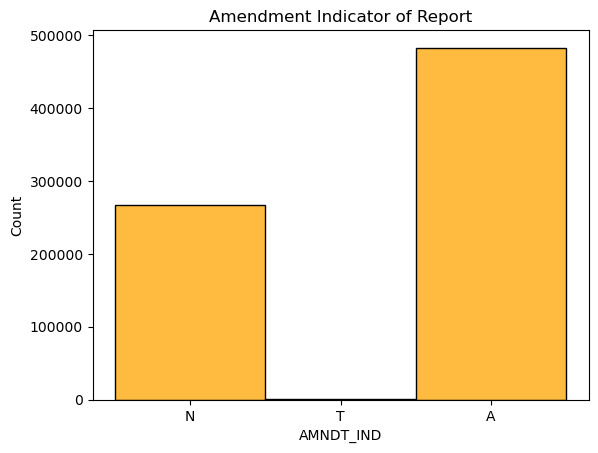

In [20]:
sns.histplot(data=cc_ie_22, x='AMNDT_IND', color='orange')
plt.title('Amendment Indicator of Report')

Note on TRAN_ID: "ONLY VALID FOR ELECTRONIC FILINGS. A unique identifier associated with each itemization or transaction appearing in an FEC electronic file. A transaction ID is unique for a specific committee for a specific report. In other words, if committee, C1, files a Q3 New with transaction SA123 and then files 3 amendments to the Q3 transaction SA123 will be identified by transaction ID SA123 in all 4 filings."

However some 'A' rows do not have a corresponding 'N' it is not immediately clear why this is but it can be assumed based on the FEC quote above that if we just take the most recent TRAN_ID in the table

In [21]:
cc_ie_22 = cc_ie_22.sort_values(["CMTE_ID", "TRAN_ID", "FILE_NUM"])
cc_ie_22 = cc_ie_22.groupby(["CMTE_ID", "TRAN_ID"], as_index=False).last().copy()

In [22]:
len(cc_ie_22)

740828

### Should we actually do EDA?

In [23]:
# Define the mapping from states to regions
state_to_region = {
    # New England
    'CT': 'New England', 'ME': 'New England', 'MA': 'New England',
    'NH': 'New England', 'RI': 'New England', 'VT': 'New England',

    # Middle Atlantic
    'NJ': 'Middle Atlantic', 'NY': 'Middle Atlantic', 'PA': 'Middle Atlantic',

    # East North Central
    'IL': 'East North Central', 'IN': 'East North Central', 'MI': 'East North Central',
    'OH': 'East North Central', 'WI': 'East North Central',

    # West North Central
    'IA': 'West North Central', 'KS': 'West North Central', 'MN': 'West North Central',
    'MO': 'West North Central', 'NE': 'West North Central',
    'ND': 'West North Central', 'SD': 'West North Central',

    # South Atlantic
    'DE': 'South Atlantic', 'DC': 'South Atlantic', 'FL': 'South Atlantic',
    'GA': 'South Atlantic', 'MD': 'South Atlantic', 'NC': 'South Atlantic',
    'SC': 'South Atlantic', 'VA': 'South Atlantic', 'WV': 'South Atlantic',

    # East South Central
    'AL': 'East South Central', 'KY': 'East South Central',
    'MS': 'East South Central', 'TN': 'East South Central',

    # West South Central
    'AR': 'West South Central', 'LA': 'West South Central',
    'OK': 'West South Central', 'TX': 'West South Central',

    # Mountain
    'AZ': 'Mountain', 'CO': 'Mountain', 'ID': 'Mountain',
    'MT': 'Mountain', 'NV': 'Mountain', 'NM': 'Mountain',
    'UT': 'Mountain', 'WY': 'Mountain',

    # Pacific
    'AK': 'Pacific', 'CA': 'Pacific', 'HI': 'Pacific',
    'OR': 'Pacific', 'WA': 'Pacific'
}

# Assume your DataFrame is called df
cand_summ_22['Cand_Region'] = cand_summ_22['Cand_Office_St'].map(state_to_region)

In [24]:
cc_ie_22.columns

Index(['CMTE_ID', 'TRAN_ID', 'AMNDT_IND', 'RPT_TP', 'TRANSACTION_PGI',
       'IMAGE_NUM', 'TRANSACTION_TP', 'ENTITY_TP', 'NAME', 'CITY', 'STATE',
       'ZIP_CODE', 'EMPLOYER', 'OCCUPATION', 'TRANSACTION_DT',
       'TRANSACTION_AMT', 'OTHER_ID', 'CAND_ID', 'FILE_NUM', 'MEMO_CD',
       'MEMO_TEXT', 'SUB_ID', 'support_oppose_flag'],
      dtype='object')

In [25]:
len(cc_ie_22[cc_ie_22['TRANSACTION_AMT'] < 0])

263800

In [26]:
contrib_totals = cc_ie_22.groupby(['CMTE_ID','CAND_ID'])['TRANSACTION_AMT'].sum().reset_index().copy()

In [27]:
contrib_totals[contrib_totals['TRANSACTION_AMT'] < 0]

,CMTE_ID,CAND_ID,TRANSACTION_AMT
664,C00000885,H8CA48035,-1000.0
703,C00000885,H8NY27176,-2500.0
745,C00000885,S8MS00287,-4000.0
783,C00000901,H0MO04086,-1000.0
785,C00000901,H0MO07113,-2500.0
...,...,...,...
135845,C00777458,S2MO00593,-1000.0
138609,C00809756,H0IA01174,-2100.0
138614,C00809756,H0TX07170,-2100.0
138617,C00809756,H2AZ02360,-2100.0


In [28]:
comm_summ_22[comm_summ_22['CMTE_ID']=='C00706267']

,Link_Image,CMTE_ID,CMTE_NM,CMTE_TP,CMTE_DSGN,CMTE_FILING_FREQ,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,...,ITEM_CONVN_EXP_DISB,ITEM_OTHER_DISB,SUBTTL_CONVN_EXP_DISB,TTL_EXP_SUBJECT_LIMITS,UNITEM_CONVN_EXP_DISB,UNITEM_OTHER_DISB,TTL_COMMUNICATION_COST,COH_BOY,COH_COY,ORG_TP
11234,https://www.fec.gov/data/committee/C00706267/?...,C00706267,ASHLEY HINSON FOR CONGRESS,H,P,Q,PO BOX 811,None,MARION,IA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


C:\Users\wkmp2\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\wkmp2\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 1.0, 'Log Transfromed Transaction Amount Distribution')

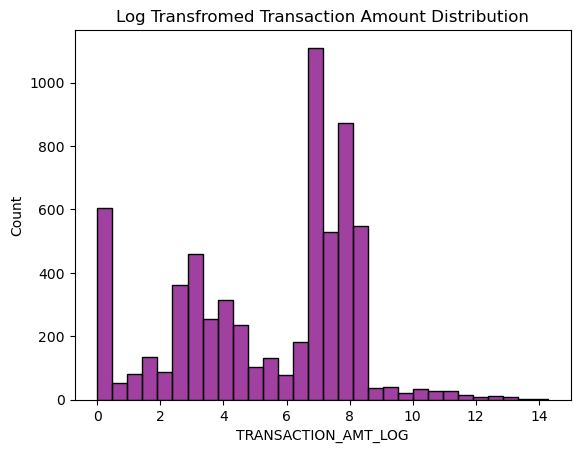

In [29]:
cc_ie_22['TRANSACTION_AMT_LOG'] = np.log1p(cc_ie_22['TRANSACTION_AMT'])

sns.histplot(data=cc_ie_22.sample(10000), x='TRANSACTION_AMT_LOG', color='purple')
plt.title("Log Transfromed Transaction Amount Distribution")

C:\Users\wkmp2\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 1.0, 'Total Amount Given by Committee')

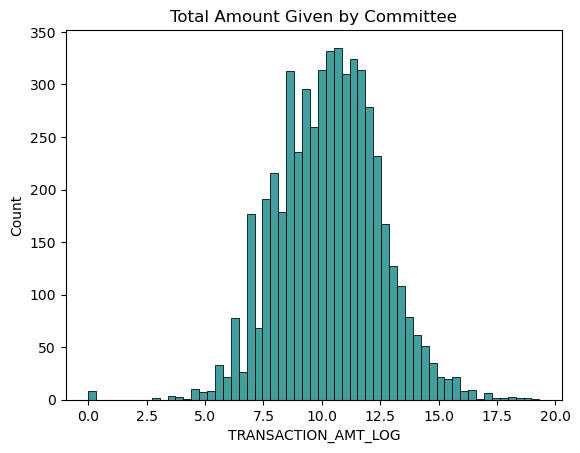

In [30]:
contrib_totals = cc_ie_22[['CMTE_ID','TRANSACTION_AMT']].groupby('CMTE_ID').sum()
contrib_totals ['TRANSACTION_AMT_LOG'] = np.log1p(contrib_totals['TRANSACTION_AMT'])

sns.histplot(data=contrib_totals, x='TRANSACTION_AMT_LOG', color='teal')
plt.title("Total Amount Given by Committee")

In [31]:
contrib_totals['TRANSACTION_AMT'].max()

246008258.0

Text(0.5, 1.0, 'Expenditures and Contributions Over 2022 Election Cycle')

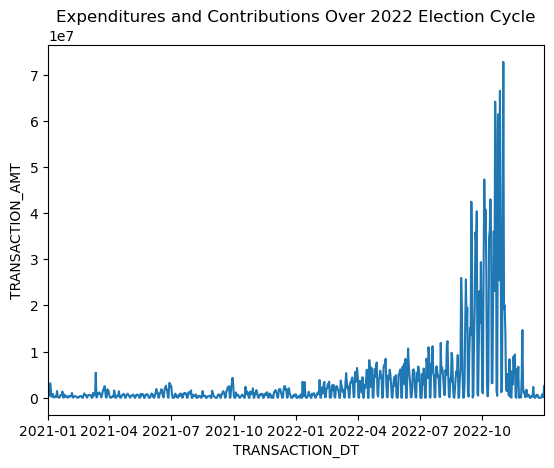

In [32]:
cc_ie_22['TRANSACTION_DT'] = pd.to_datetime(cc_ie_22['TRANSACTION_DT'])
daily = cc_ie_22[['TRANSACTION_DT','TRANSACTION_AMT']].groupby('TRANSACTION_DT').sum()

sns.lineplot(data=daily, x='TRANSACTION_DT', y='TRANSACTION_AMT')
plt.xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-31'))
plt.title('Expenditures and Contributions Over 2022 Election Cycle')

C:\Users\wkmp2\AppData\Local\Temp\ipykernel_23560\980168714.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=w_can_info, x='Cand_Party_Affiliation', y='TRANSACTION_AMT', palette=['blue','purple','red'])


Text(0.5, 1.0, 'Total Support Recieved By Party During 2022 Election Cycle')

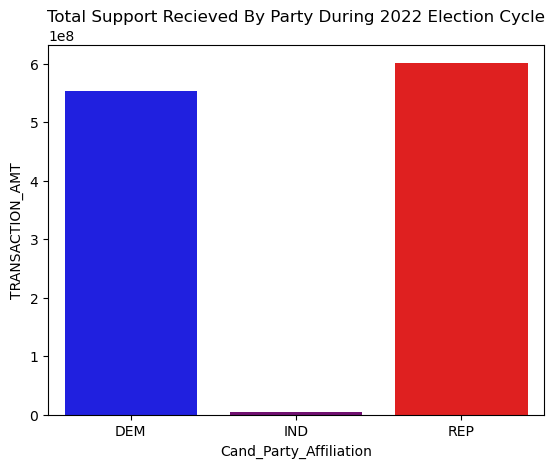

In [33]:
w_can_info = pd.merge(cand_summ_22, cc_ie_22, left_on='Cand_Id', right_on='CAND_ID')

w_can_info = w_can_info[(w_can_info['support_oppose_flag'] != 'O') & ( (w_can_info['Cand_Party_Affiliation'] == 'DEM') | (w_can_info['Cand_Party_Affiliation'] == 'REP') | (w_can_info['Cand_Party_Affiliation'] == 'IND'))].copy()

w_can_info = w_can_info[['Cand_Party_Affiliation','TRANSACTION_AMT']].groupby('Cand_Party_Affiliation').sum()

sns.barplot(data=w_can_info, x='Cand_Party_Affiliation', y='TRANSACTION_AMT', palette=['blue','purple','red'])
plt.title('Total Support Recieved By Party During 2022 Election Cycle')

## Class Today We Will Be Classifying

In [122]:
house_22_results = house_22_results[['FEC ID','GE WINNER INDICATOR']].copy()
house_22_winners = house_22_results[house_22_results['GE WINNER INDICATOR'] == 'W']

senate_22_results = senate_22_results[['FEC ID','GE WINNER INDICATOR']].copy()
senate_22_winners = senate_22_results[senate_22_results['GE WINNER INDICATOR'] == 'W']

winners_22 = pd.concat([house_22_winners, senate_22_winners])

In [123]:
winners_22.drop_duplicates()

,FEC ID,GE WINNER INDICATOR
1,H0AL01055,W
6,H8AL02171,W
14,H2AL03032,W
23,H6AL04098,W
31,H2AL05102,W
...,...,...
567,S2SD00068,W
575,S0UT00165,W
593,S2VT00235,W
615,S2WA00189,W


In [174]:
interaction_matrix = (
    cc_ie_22[cc_ie_22['support_oppose_flag']=='S'].pivot_table(
        index="CAND_ID",          # rows
        columns="CMTE_ID",        # columns
        values="TRANSACTION_AMT", # cell values
        aggfunc="sum",            # sum of transactions
        fill_value=0              # replace NaNs with 0
    )
)

In [175]:
import umap.umap_ as umap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# pivot table creation, and feature engineering!!

scaler = StandardScaler()

#30 #20
svd = TruncatedSVD(n_components=20, random_state=56)
latent = svd.fit_transform(interaction_matrix)
scaler_latent = scaler.fit_transform(latent)

scaled_latent_df = pd.DataFrame(
    scaler_latent,
    index=interaction_matrix.index,
    columns=[f"latent_{i+1}" for i in range(scaler_latent.shape[1])]
)

In [176]:
latent_winners = pd.merge(scaled_latent_df, winners_22, right_on='FEC ID', left_index=True, how='left').set_index('FEC ID')

In [177]:
latent_winners['GE WINNER INDICATOR'] = latent_winners['GE WINNER INDICATOR'] == 'W'

In [178]:
latent_winners

,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,...,latent_12,latent_13,latent_14,latent_15,latent_16,latent_17,latent_18,latent_19,latent_20,GE WINNER INDICATOR
FEC ID,,,,,,,,,,,,,,,,,,,,,
H0AL01055,-0.066978,-0.053194,-0.021577,-0.020349,0.003812,-0.048038,0.004024,0.024996,0.007248,-0.021390,...,-0.039532,-0.042863,-0.045077,0.006884,-0.022002,-0.021204,-0.022096,-0.023969,-0.031453,True
H0AL02087,-0.067947,-0.053451,-0.022193,-0.021258,0.003226,-0.048206,0.003835,0.025343,0.008013,-0.004666,...,-0.026108,-0.042975,-0.066289,-0.020666,-0.019546,-0.021279,-0.022203,-0.021183,-0.033965,False
H0AL02202,-0.067947,-0.053451,-0.022193,-0.021258,0.003226,-0.048206,0.003835,0.025343,0.008013,-0.004666,...,-0.026108,-0.042975,-0.066289,-0.020665,-0.019546,-0.021279,-0.022203,-0.021183,-0.033965,False
H0AL05163,-0.067381,-0.053454,-0.022239,-0.021257,0.002636,-0.048209,0.003843,0.025005,0.008022,-0.005669,...,-0.021350,-0.042976,-0.067515,-0.022515,-0.019388,-0.021262,-0.021719,-0.019658,-0.033857,False
H0AL07086,-0.067653,-0.050734,-0.022006,-0.021200,0.002583,-0.047714,0.004344,0.024705,0.005471,-0.004588,...,-0.024018,-0.038274,-0.040523,-0.006053,-0.020960,-0.021152,0.000584,-0.023849,-0.036718,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S8TX00285,-0.067947,-0.053450,-0.022193,-0.021258,0.003226,-0.048206,0.003835,0.025343,0.008014,-0.004666,...,-0.026108,-0.042974,-0.066288,-0.020664,-0.019546,-0.021279,-0.022197,-0.021183,-0.033960,False
S8UT00176,-0.063975,-0.053402,-0.018406,-0.014987,0.005224,-0.048195,0.003870,0.023579,0.007860,-0.165563,...,-0.156222,-0.042868,0.018399,0.191962,-0.038267,-0.020432,-0.049922,-0.035349,-0.035599,False
S8WA00194,-0.067947,-0.053421,-0.022193,-0.021258,0.003227,-0.048200,0.003812,0.025349,0.007994,-0.004662,...,-0.026111,-0.042984,-0.066202,-0.020647,-0.019547,-0.021281,-0.022125,-0.021200,-0.033732,False


### Winner Winner

In [206]:
from sklearn.model_selection import train_test_split

# 'month_avg','curr_total','avg_watched','recent_watched','pub_prct_prev','pub_prct_curr'
X_train, X_test, y_train, y_test = train_test_split(latent_winners.drop(columns=['GE WINNER INDICATOR']), latent_winners['GE WINNER INDICATOR'], test_size=0.2, random_state=42)
X_train = X_train
X_test = X_test

In [207]:
incumb_pred = pd.merge(latent_winners['GE WINNER INDICATOR'],cand_summ_22[['Cand_Id','Cand_Incumbent_Challenger_Open_Seat']], left_index=True, right_on='Cand_Id',how='left')

In [208]:
incumb_pred['IS_INCUMB'] = (
    incumb_pred['Cand_Incumbent_Challenger_Open_Seat'] == 'INCUMBENT'
).astype(float)

In [209]:
incumb_pred.set_index('Cand_Id', inplace=True)

In [210]:
incumb_pred

,GE WINNER INDICATOR,Cand_Incumbent_Challenger_Open_Seat,IS_INCUMB
Cand_Id,,,
H0AL01055,True,INCUMBENT,1.0
H0AL02087,False,NaN,0.0
H0AL02202,False,CHALLENGER,0.0
H0AL05163,False,NaN,0.0
H0AL07086,True,INCUMBENT,1.0
...,...,...,...
S8TX00285,False,NaN,0.0
S8UT00176,False,NaN,0.0
S8WA00194,False,NaN,0.0


In [211]:
print(len(incumb_pred))
print(len(y_test))
print(len(y_train))

2195
439
1756


In [212]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),  
    ("rf", RandomForestClassifier(
        n_estimators=200, 
        max_depth=20, 
        random_state=56,
        n_jobs=-1
    ))
])

# Fit model
rf_pipeline.fit(X_train, y_train)

# Predict probabilities
rf_pred_proba = rf_pipeline.predict_proba(X_test)
rf_churn_prob = rf_pred_proba[:, 1]

# Apply custom threshold
threshold = 0.5  # stricter threshold
y_pred_custom = (rf_churn_prob >= threshold).astype(int)

# Evaluate
print("\n=== Random Forest Model ===")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))
print("Number of test samples:", len(y_test))



=== Random Forest Model ===
Accuracy: 0.9020501138952164
              precision    recall  f1-score   support

       False       0.92      0.95      0.93       322
        True       0.84      0.78      0.81       117

    accuracy                           0.90       439
   macro avg       0.88      0.86      0.87       439
weighted avg       0.90      0.90      0.90       439

Number of test samples: 439


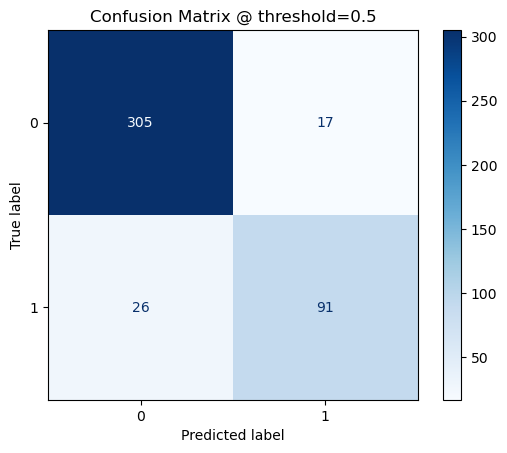

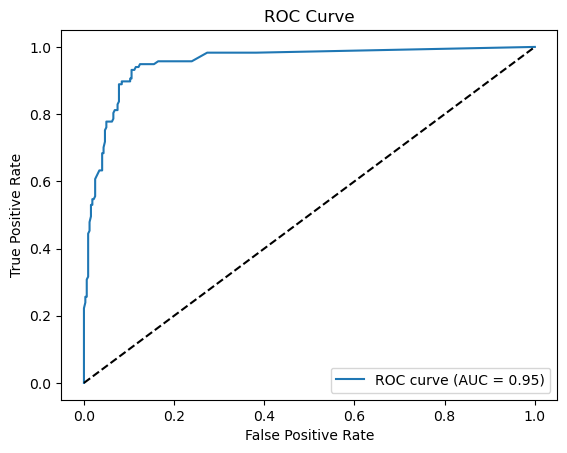

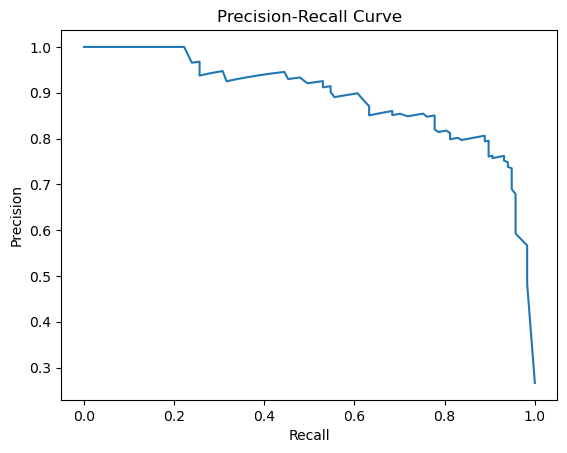

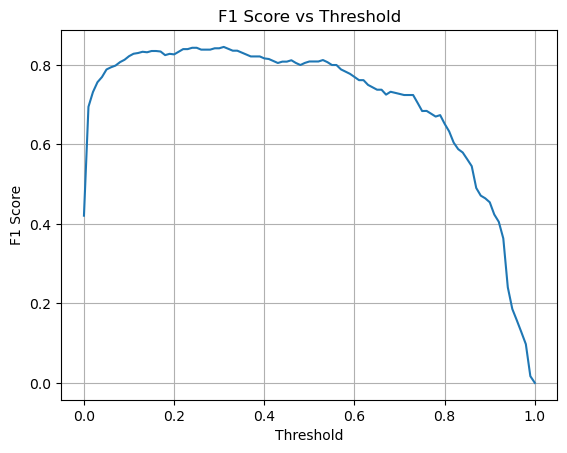

In [213]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    f1_score
)
import numpy as np

y_true = y_test # Ground truth (1=churn, 0=human)
y_scores = rf_pred_proba[:, 1]       # Predicted bot score
#y_pred = [(1,1) for _ in range(200)]

# Confusion matrix at default threshold (0.5)

threshold = 0.5
y_pred = (y_scores >= threshold).astype(int)
#y_pred = y_scores = [1 for _ in range(200)]


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix @ threshold={threshold}')
plt.show()


# ROC Curve

fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Precision-Recall Curve

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)

plt.figure()
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# F1 vs Threshold Curve

f1_scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    preds = (y_scores >= t).astype(int)
    f1_scores.append(f1_score(y_true, preds))

plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid(True)
plt.show()


In [217]:
# Evaluate
incumb_pred_unique = incumb_pred[~incumb_pred.index.duplicated(keep='first')]

print("\n=== Incumbent Model ===")
print("Accuracy:", accuracy_score(y_test, incumb_pred_unique.loc[y_test.index, 'IS_INCUMB']))
print(classification_report(y_test, incumb_pred_unique.loc[y_test.index, 'IS_INCUMB']))
print("Number of test samples:", len(y_test))


=== Incumbent Model ===
Accuracy: 0.8997722095671982
              precision    recall  f1-score   support

       False       0.92      0.95      0.93       322
        True       0.85      0.76      0.80       117

    accuracy                           0.90       439
   macro avg       0.88      0.86      0.87       439
weighted avg       0.90      0.90      0.90       439

Number of test samples: 439


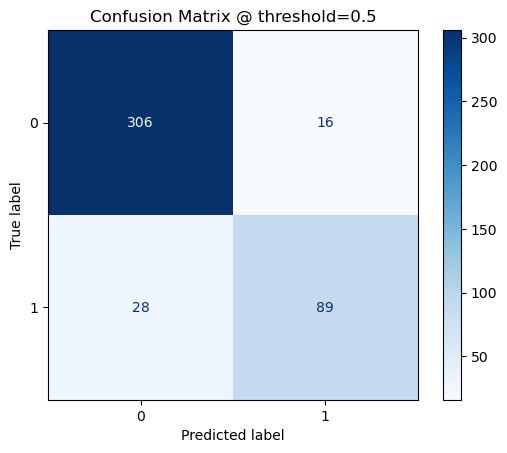

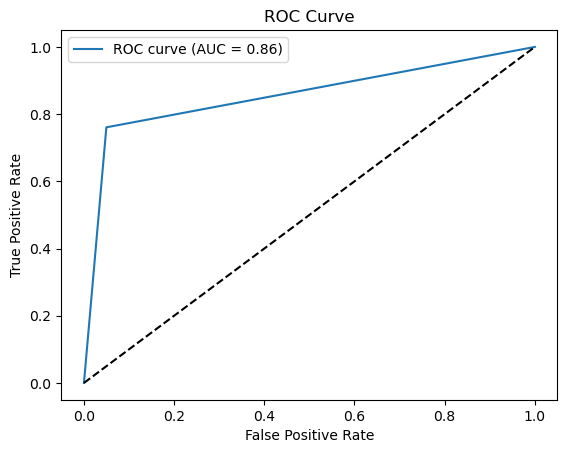

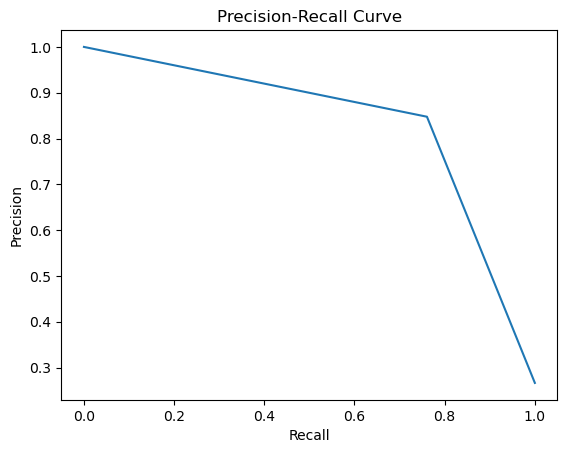

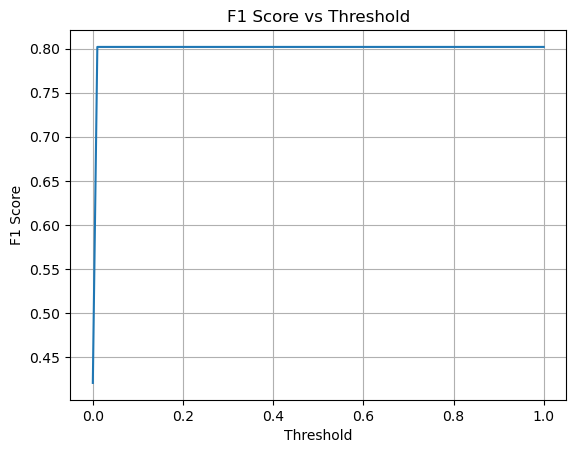

In [215]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    f1_score
)
import numpy as np

y_true = y_test # Ground truth (1=churn, 0=human)
y_scores = incumb_pred_unique.loc[y_test.index, 'IS_INCUMB']    
#y_pred = [(1,1) for _ in range(200)]

# Confusion matrix at default threshold (0.5)

threshold = 0.5
y_pred = (y_scores >= threshold).astype(int)
#y_pred = y_scores = [1 for _ in range(200)]


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix @ threshold={threshold}')
plt.show()


# ROC Curve

fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Precision-Recall Curve

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)

plt.figure()
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# F1 vs Threshold Curve

f1_scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    preds = (y_scores >= t).astype(int)
    f1_scores.append(f1_score(y_true, preds))

plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid(True)
plt.show()


### Dude, What's The Party Like?

In [188]:
latent_party_22 = pd.merge(cand_summ_22[['Cand_Id','Cand_Party_Affiliation']], scaled_latent_df, left_on='Cand_Id', right_on='CAND_ID')

In [189]:
latent_party_22['IS_REP'] = latent_party_22['Cand_Party_Affiliation'] == 'REP'

In [190]:
latent_party_22_rep = latent_party_22.drop(columns='Cand_Party_Affiliation').copy()

In [191]:
latent_party_22_rep.set_index('Cand_Id', inplace=True)

In [192]:
from sklearn.model_selection import train_test_split

# 'month_avg','curr_total','avg_watched','recent_watched','pub_prct_prev','pub_prct_curr'
X_train, X_test, y_train, y_test = train_test_split(latent_party_22_rep.drop(columns=['IS_REP']), latent_party_22_rep['IS_REP'], test_size=0.2, random_state=42)
X_train = X_train
X_test = X_test

In [199]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),  
    ("rf", RandomForestClassifier(
        n_estimators=200, 
        max_depth=20, 
        random_state=56,
        n_jobs=-1
    ))
])

# Fit model
rf_pipeline.fit(X_train, y_train)

# Predict probabilities
rf_pred_proba = rf_pipeline.predict_proba(X_test)
rf_churn_prob = rf_pred_proba[:, 1]

# Apply custom threshold
threshold = 0.5  # stricter threshold
y_pred_custom = (rf_churn_prob >= threshold).astype(int)

# Evaluate
print("\n=== Random Forest Model ===")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))
print("Number of test samples:", len(y_test))


"""
# Get Gini feature importances from RandomForest
gini_importances = rf_pipeline.named_steps["rf"].feature_importances_
print("Gini Importances:", gini_importances)

# Use actual feature names
feature_names = X_train.columns

# Create a DataFrame for better readability
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gini_importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance Ranking:")
print(importance_df)
"""



=== Random Forest Model ===
Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

       False       0.91      0.95      0.93       144
        True       0.96      0.92      0.94       171

    accuracy                           0.93       315
   macro avg       0.93      0.93      0.93       315
weighted avg       0.93      0.93      0.93       315

Number of test samples: 315


'\n# Get Gini feature importances from RandomForest\ngini_importances = rf_pipeline.named_steps["rf"].feature_importances_\nprint("Gini Importances:", gini_importances)\n\n# Use actual feature names\nfeature_names = X_train.columns\n\n# Create a DataFrame for better readability\nimportance_df = pd.DataFrame({\n    \'Feature\': feature_names,\n    \'Importance\': gini_importances\n}).sort_values(by=\'Importance\', ascending=False)\n\nprint("\nFeature Importance Ranking:")\nprint(importance_df)\n'

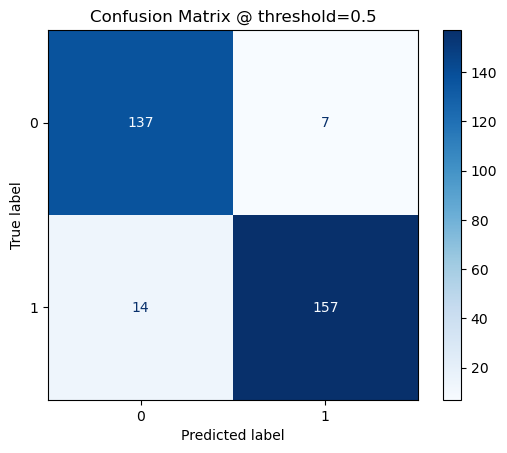

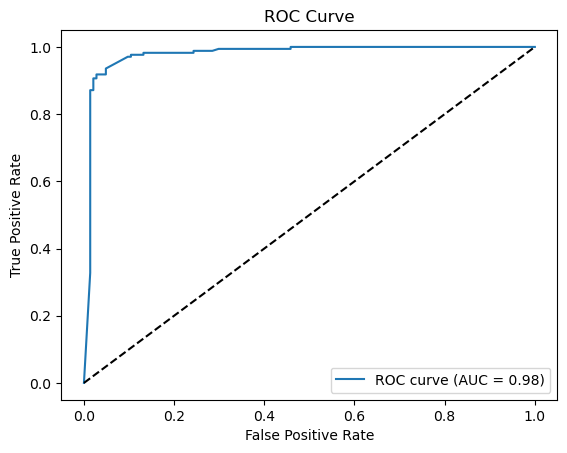

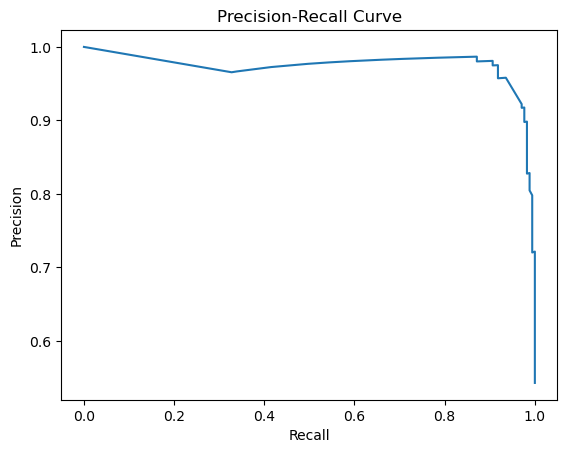

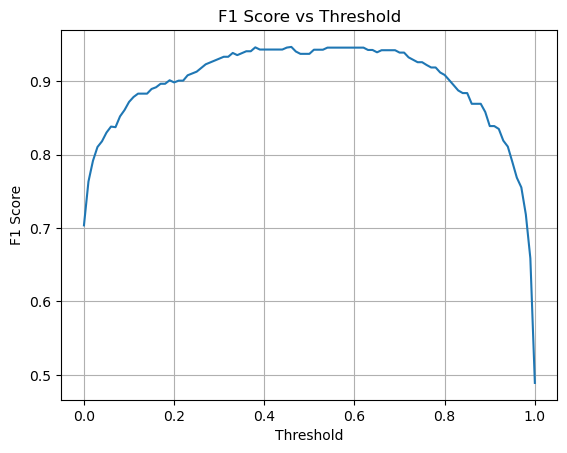

In [194]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    f1_score
)
import numpy as np

y_true = y_test # Ground truth (1=churn, 0=human)
y_scores = rf_pred_proba[:, 1]       # Predicted bot score
#y_pred = [(1,1) for _ in range(200)]

# Confusion matrix at default threshold (0.5)

threshold = 0.5
y_pred = (y_scores >= threshold).astype(int)
#y_pred = y_scores = [1 for _ in range(200)]


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix @ threshold={threshold}')
plt.show()


# ROC Curve

fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Precision-Recall Curve

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)

plt.figure()
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# F1 vs Threshold Curve

f1_scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    preds = (y_scores >= t).astype(int)
    f1_scores.append(f1_score(y_true, preds))

plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid(True)
plt.show()


In [195]:
p = y_train.mean()  # prevalence of winners in training set

# Random predictions with same class distribution
random_preds = np.random.binomial(1, p, size=len(y_test))

print("\n=== Random Baseline Model ===")
print("Accuracy:", accuracy_score(y_test, random_preds))
print(classification_report(y_test, random_preds))


=== Random Baseline Model ===
Accuracy: 0.5365079365079365
              precision    recall  f1-score   support

       False       0.49      0.46      0.47       144
        True       0.57      0.60      0.59       171

    accuracy                           0.54       315
   macro avg       0.53      0.53      0.53       315
weighted avg       0.53      0.54      0.53       315



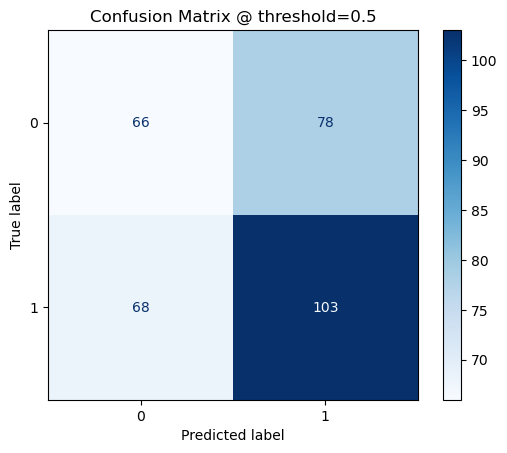

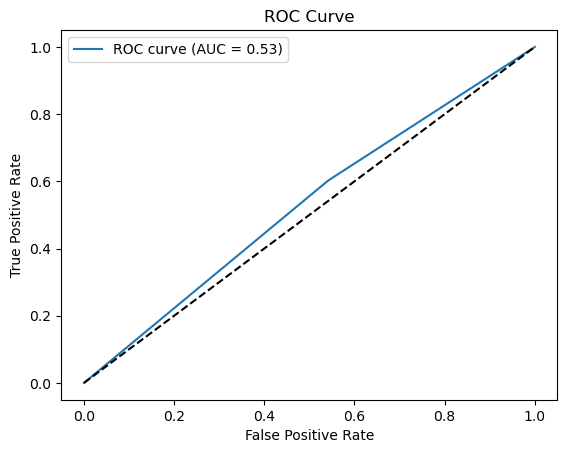

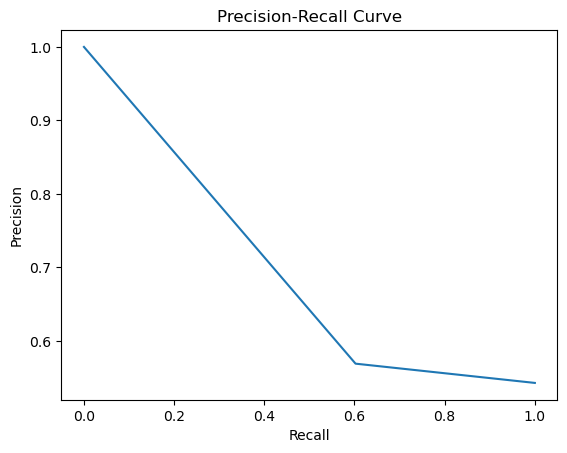

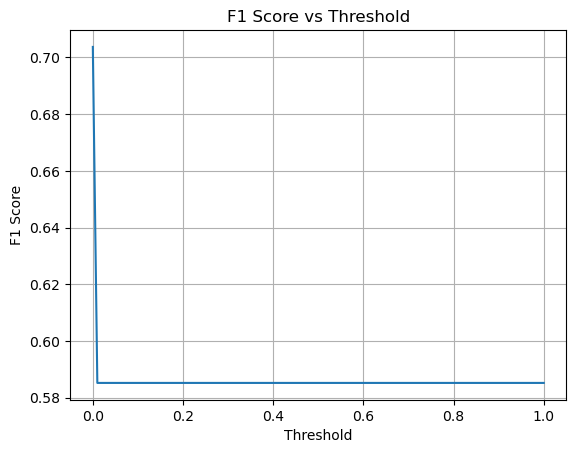

In [197]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    f1_score
)
import numpy as np

y_true = y_test # Ground truth (1=churn, 0=human)
y_scores = random_preds       # Predicted bot score
#y_pred = [(1,1) for _ in range(200)]

# Confusion matrix at default threshold (0.5)

threshold = 0.5
y_pred = (y_scores >= threshold).astype(int)
#y_pred = y_scores = [1 for _ in range(200)]


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix @ threshold={threshold}')
plt.show()


# ROC Curve

fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Precision-Recall Curve

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)

plt.figure()
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# F1 vs Threshold Curve

f1_scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    preds = (y_scores >= t).astype(int)
    f1_scores.append(f1_score(y_true, preds))

plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid(True)
plt.show()


### Incumb Here Often?

In [221]:
latent_incumb_22 = pd.merge(cand_summ_22[['Cand_Id','Cand_Incumbent_Challenger_Open_Seat']], scaled_latent_df, left_on='Cand_Id', right_on='CAND_ID')
latent_incumb_22['IS_INCUMB'] = latent_incumb_22['Cand_Incumbent_Challenger_Open_Seat'] == 'INCUMBENT'
latent_incumb_22 = latent_incumb_22.drop(columns='Cand_Incumbent_Challenger_Open_Seat').copy()
latent_incumb_22.set_index('Cand_Id', inplace=True)

In [226]:
from sklearn.model_selection import train_test_split

# 'month_avg','curr_total','avg_watched','recent_watched','pub_prct_prev','pub_prct_curr'
X_train, X_test, y_train, y_test = train_test_split(latent_incumb_22.drop(columns=['IS_INCUMB']), latent_incumb_22['IS_INCUMB'], test_size=0.2, random_state=42)
X_train = X_train
X_test = X_test

In [227]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),  
    ("rf", RandomForestClassifier(
        n_estimators=200, 
        max_depth=20, 
        random_state=56,
        n_jobs=-1
    ))
])

# Fit model
rf_pipeline.fit(X_train, y_train)

# Predict probabilities
rf_pred_proba = rf_pipeline.predict_proba(X_test)
rf_churn_prob = rf_pred_proba[:, 1]

# Apply custom threshold
threshold = 0.5  # stricter threshold
y_pred_custom = (rf_churn_prob >= threshold).astype(int)

# Evaluate
print("\n=== Random Forest Model ===")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))
print("Number of test samples:", len(y_test))



=== Random Forest Model ===
Accuracy: 0.9365079365079365
              precision    recall  f1-score   support

       False       0.95      0.96      0.95       216
        True       0.92      0.88      0.90        99

    accuracy                           0.94       315
   macro avg       0.93      0.92      0.93       315
weighted avg       0.94      0.94      0.94       315

Number of test samples: 315


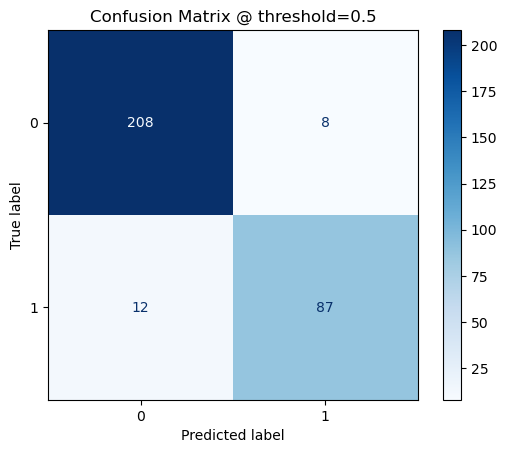

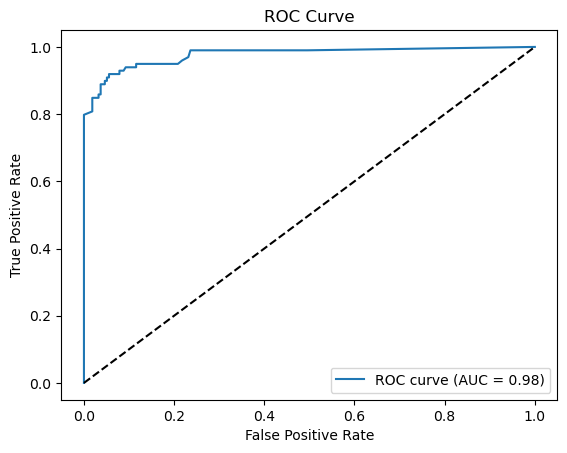

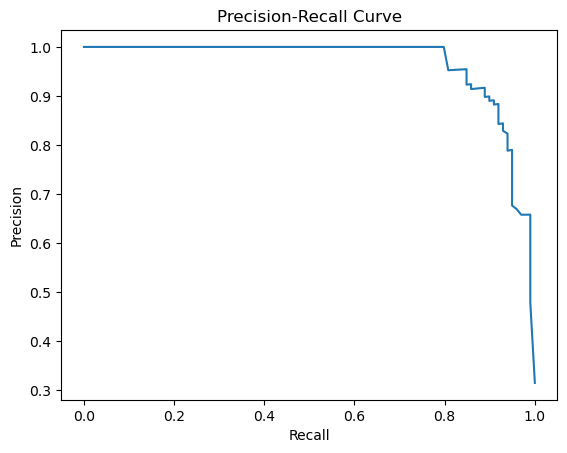

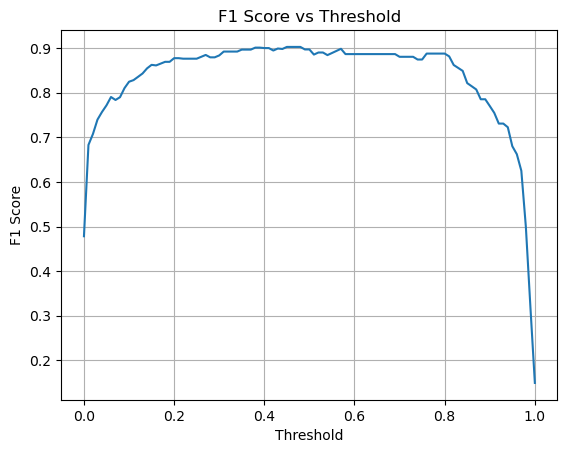

In [230]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    f1_score
)
import numpy as np

y_true = y_test # Ground truth (1=churn, 0=human)
y_scores = rf_pred_proba[:, 1]       # Predicted bot score
#y_pred = [(1,1) for _ in range(200)]

# Confusion matrix at default threshold (0.5)

threshold = 0.5
y_pred = (y_scores >= threshold).astype(int)
#y_pred = y_scores = [1 for _ in range(200)]


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix @ threshold={threshold}')
plt.show()


# ROC Curve

fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Precision-Recall Curve

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)

plt.figure()
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# F1 vs Threshold Curve

f1_scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    preds = (y_scores >= t).astype(int)
    f1_scores.append(f1_score(y_true, preds))

plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid(True)
plt.show()


In [233]:
p = y_train.mean()  # prevalence of winners in training set

# Random predictions with same class distribution
random_preds = np.random.binomial(1, p, size=len(y_test))

print("\n=== Random Baseline Model ===")
print("Accuracy:", accuracy_score(y_test, random_preds))
print(classification_report(y_test, random_preds))


=== Random Baseline Model ===
Accuracy: 0.5904761904761905
              precision    recall  f1-score   support

       False       0.68      0.76      0.72       216
        True       0.29      0.21      0.25        99

    accuracy                           0.59       315
   macro avg       0.49      0.49      0.48       315
weighted avg       0.56      0.59      0.57       315



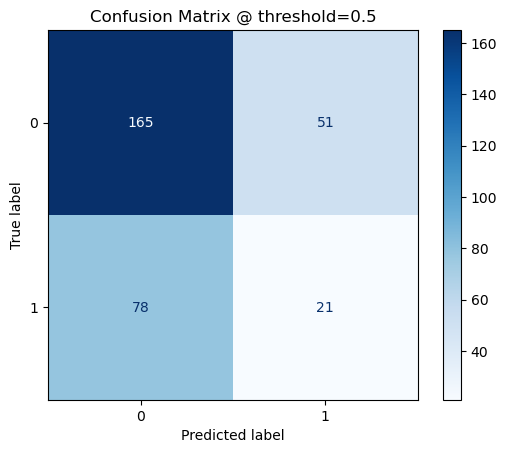

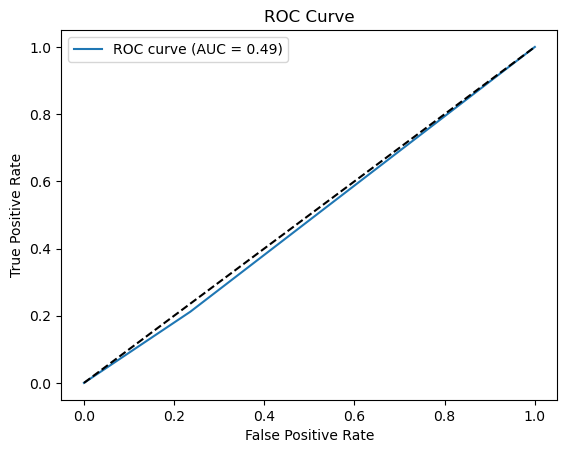

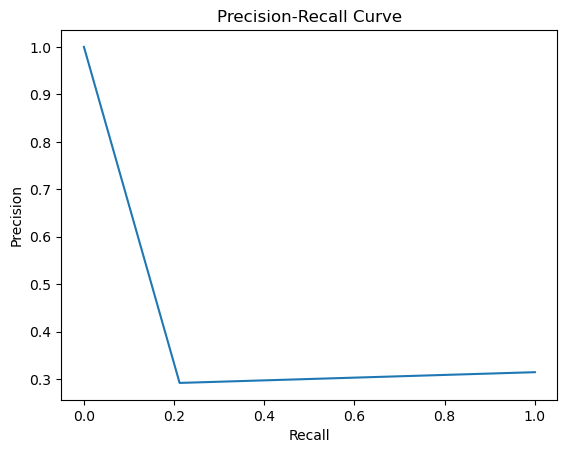

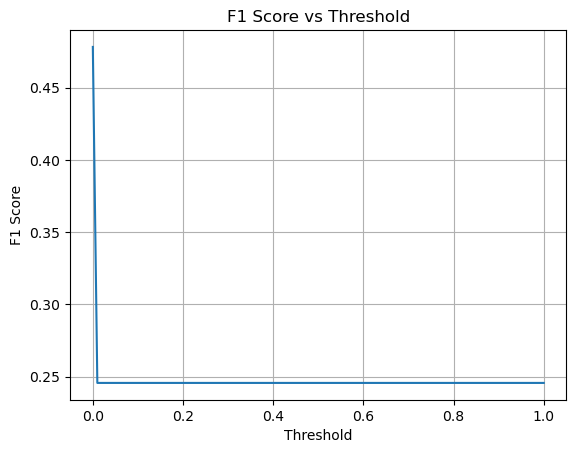

In [234]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    f1_score
)
import numpy as np

y_true = y_test # Ground truth (1=churn, 0=human)
y_scores = random_preds       # Predicted bot score
#y_pred = [(1,1) for _ in range(200)]

# Confusion matrix at default threshold (0.5)

threshold = 0.5
y_pred = (y_scores >= threshold).astype(int)
#y_pred = y_scores = [1 for _ in range(200)]


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix @ threshold={threshold}')
plt.show()


# ROC Curve

fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Precision-Recall Curve

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)

plt.figure()
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# F1 vs Threshold Curve

f1_scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    preds = (y_scores >= t).astype(int)
    f1_scores.append(f1_score(y_true, preds))

plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid(True)
plt.show()


### Committee Cluster

In [99]:
interaction_matrix = (
    cc_ie_22.pivot_table(
        index="CMTE_ID",          # rows
        columns="CAND_ID",        # columns
        values="TRANSACTION_AMT", # cell values
        aggfunc="sum",            # sum of transactions
        fill_value=0              # replace NaNs with 0
    )
)

C:\Users\wkmp2\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\wkmp2\AppData\Local\Temp\ipykernel_40776\1542835625.py:29: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

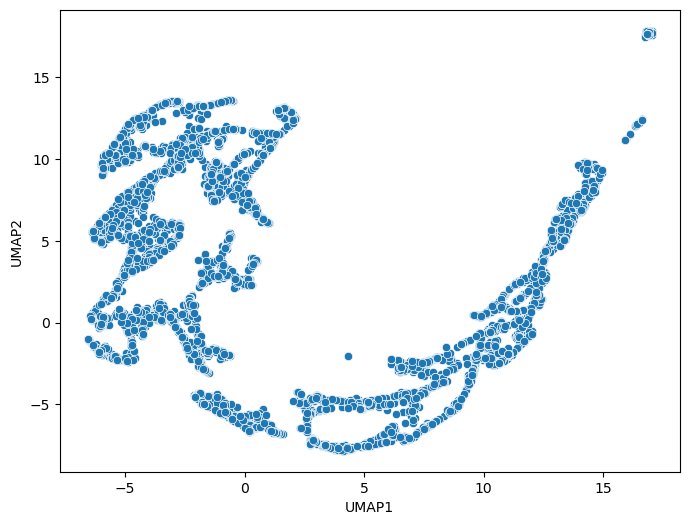

In [121]:
import umap.umap_ as umap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# pivot table creation, and feature engineering!!

scaler = StandardScaler()

#30 #20
svd = TruncatedSVD(n_components=6, random_state=56)
latent = svd.fit_transform(interaction_matrix)
scaler_latent = scaler.fit_transform(latent)

scaled_latent_df = pd.DataFrame(
    scaler_latent,
    index=interaction_matrix.index,
    columns=[f"latent_{i+1}" for i in range(scaler_latent.shape[1])]
)

reducer = umap.UMAP(random_state=26)
embedding = reducer.fit_transform(scaled_latent_df)

embeddings_df = pd.DataFrame(embedding, index= scaled_latent_df.index, columns=["UMAP1","UMAP2"])
#embeddings_with_clusters = pd.merge(cluster_labels, embeddings_df, left_index=True, right_index=True)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=embeddings_df,
    x="UMAP1",y="UMAP2",
    palette='mako'
)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

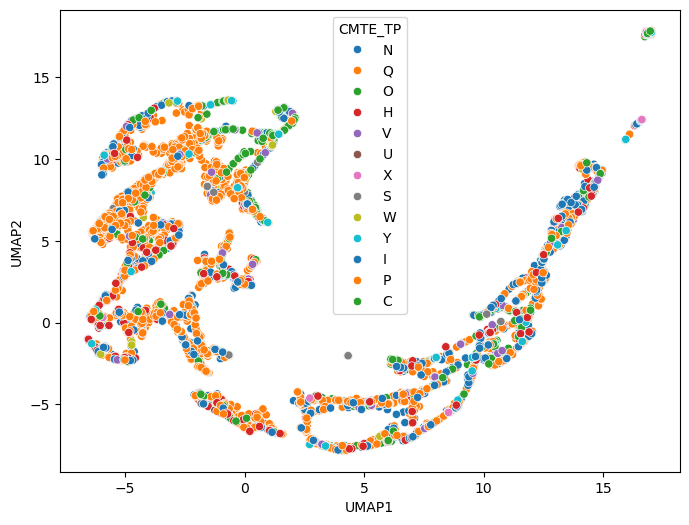

In [113]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pd.merge(comm_summ_22, embeddings_df, left_on='CMTE_ID', right_on='CMTE_ID'),
    x="UMAP1",y="UMAP2",
    palette = "tab10",
    hue='CMTE_TP'
)

In [131]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.cluster import HDBSCAN
from sklearn.cluster import AffinityPropagation
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

#dbscan = DBSCAN(eps= 1.5, min_samples = 10)
#clusters = dbscan.fit_predict(scaled_latent_df)

"""
for eps in [0.1, 0.3, 0.5, 0.7, 1.0]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    clusters = dbscan.fit_predict(scaled_latent_df)
    print(f"eps={eps}: {len(set(clusters)) - (1 if -1 in clusters else 0)} clusters, {sum(clusters == -1)} noise points")
"""

hdbscan = HDBSCAN(min_cluster_size= 30, min_samples = 2)
clusters = hdbscan.fit_predict(scaled_latent_df)

#kmeans = KMeans(n_clusters=6, random_state=65)
#clusters = kmeans.fit_predict(scaled_latent_df)

#ap = AffinityPropagation(damping = 0.9, preference = -50)
#clusters = ap.fit_predict(scaled_latent_df)

#gmm = GaussianMixture(n_components=8,covariance_type='full',random_state=56)
#clusters = gmm.fit_predict(scaled_latent_df)

"""results = []

for n in range(2,11):
    gmm = GaussianMixture(n_components=n,covariance_type='full',random_state=56)
    clusters = gmm.fit_predict(scaled_latent_df)

    score = silhouette_score(scaled_latent_df,clusters)
    results.append({'n_clusters': n, 'silhoutte_score':score})

silt_df = pd.DataFrame(results)"""

cluster_labels = pd.DataFrame(clusters, index=scaled_latent_df.index,columns=['cluster'])

C:\Users\wkmp2\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

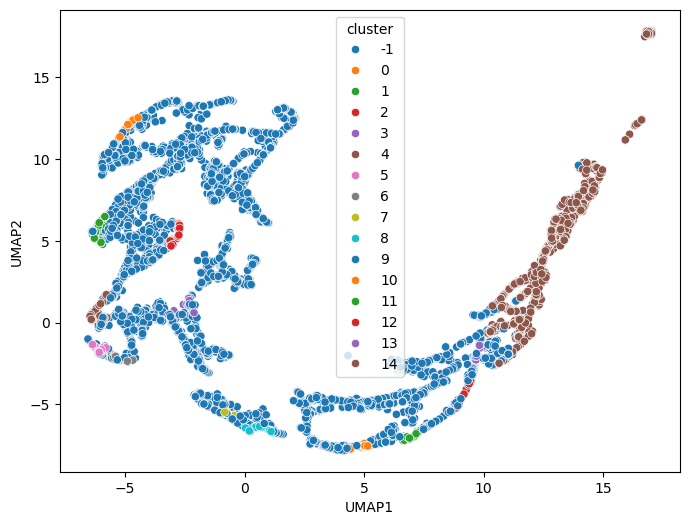

In [132]:
import umap.umap_ as umap
import seaborn as sns
import matplotlib.pyplot as plt

reducer = umap.UMAP(random_state=26)
embedding = reducer.fit_transform(scaled_latent_df)

embeddings_df = pd.DataFrame(embedding, index= scaled_latent_df.index, columns=["UMAP1","UMAP2"])
embeddings_with_clusters = pd.merge(cluster_labels, embeddings_df, left_index=True, right_index=True)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=embeddings_with_clusters,
    x="UMAP1",y="UMAP2",
    palette = "tab10",
    hue='cluster'
)

In [126]:
scaled_latent_df

,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6
CMTE_ID,,,,,,
C00000059,-0.035086,-0.028222,-0.014702,-0.029339,0.020632,-0.028641
C00000422,-0.033925,-0.027902,-0.015070,-0.017899,0.013797,-0.024385
C00000729,-0.033639,-0.027636,-0.015276,-0.009091,0.013167,-0.024011
C00000885,-0.022780,-0.030318,-0.018485,-0.016785,0.014225,-0.020900
C00000901,-0.032461,-0.016191,-0.002698,0.021426,0.024298,-0.014241
...,...,...,...,...,...,...
C90021965,-0.035071,-0.028104,-0.014708,-0.029460,0.020348,-0.028275
C90021973,-0.035084,-0.028216,-0.014704,-0.029465,0.020571,-0.028639
C90021981,-0.034861,-0.028306,-0.014703,-0.029501,0.020558,-0.028963


In [135]:
pd.merge(comm_summ_22, cluster_labels[cluster_labels['cluster'] == 2], left_on='CMTE_ID', right_on='CMTE_ID').sample(5)

,Link_Image,CMTE_ID,CMTE_NM,CMTE_TP,CMTE_DSGN,CMTE_FILING_FREQ,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,...,ITEM_OTHER_DISB,SUBTTL_CONVN_EXP_DISB,TTL_EXP_SUBJECT_LIMITS,UNITEM_CONVN_EXP_DISB,UNITEM_OTHER_DISB,TTL_COMMUNICATION_COST,COH_BOY,COH_COY,ORG_TP,cluster
44,https://www.fec.gov/data/committee/C00794685/?...,C00794685,HONEY BADGER PAC,N,D,Q,50 S JONES BLVD STE 201,None,LAS VEGAS,NV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2
18,https://www.fec.gov/data/committee/C00343681/?...,C00343681,"PECKHAM INDUSTRIES, INC. FEDERAL PAC",Q,U,Q,20 HAARLEM AVENUE,None,WHITE PLAINS,NY,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,2
1,https://www.fec.gov/data/committee/C00390724/?...,C00390724,WALBERG FOR CONGRESS,H,P,Q,PO BOX 1362,317 W WASHINGTON AVE,JACKSON,MI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2
39,https://www.fec.gov/data/committee/C00819987/?...,C00819987,NEVADA FOR FREEDOM,O,U,Q,PO BOX 183,None,HUDSON,WI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2
38,https://www.fec.gov/data/committee/C00099002/?...,C00099002,"SUNKIST GROWERS, INC. PAC - FEDERAL",Q,U,M,27770 N. ENTERTAINMENT DRIVE,None,VALENCIA,CA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,V,2


### This is such a Cluster f-

In [235]:
interaction_matrix = (
    cc_ie_22[cc_ie_22['support_oppose_flag']=='S'].pivot_table(
        index="CAND_ID",          # rows
        columns="CMTE_ID",        # columns
        values="TRANSACTION_AMT", # cell values
        aggfunc="sum",            # sum of transactions
        fill_value=0              # replace NaNs with 0
    )
)

In [155]:

candidate_totals = interaction_matrix.sum(axis=1)

interaction_matrix_scaled = interaction_matrix.div(candidate_totals, axis=0)

In [157]:
interaction_matrix_scaled

CMTE_ID,C00000059,C00000422,C00000729,C00000885,C00000901,C00000935,C00000984,C00001016,C00001198,C00001214,...,C90021866,C90021882,C90021890,C90021924,C90021932,C90021965,C90021973,C90021981,C90021999,C90022005
CAND_ID,,,,,,,,,,,,,,,,,,,,,
H0AL01055,0.0,0.00000,0.002012,0.0,0.011066,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H0AL02087,-0.0,-0.00000,-0.000000,-0.0,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
H0AL02202,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H0AL05163,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H0AL07086,0.0,0.00274,0.001918,0.0,0.001918,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S8TX00285,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S8UT00176,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S8WA00194,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
interaction_matrix.max().max()

54905733.0

In [68]:
interaction_matrix.max(axis=1).idxmax()

'S2GA00225'

In [70]:
interaction_matrix.loc['S2GA00225'].idxmax(axis=0)

'C00763193'

In [54]:
contrib_totals['TRANSACTION_AMT'].max()

54905733.0

In [74]:
comm_summ_22[comm_summ_22['CMTE_ID'] == 'C00763193']

,Link_Image,CMTE_ID,CMTE_NM,CMTE_TP,CMTE_DSGN,CMTE_FILING_FREQ,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,...,ITEM_CONVN_EXP_DISB,ITEM_OTHER_DISB,SUBTTL_CONVN_EXP_DISB,TTL_EXP_SUBJECT_LIMITS,UNITEM_CONVN_EXP_DISB,UNITEM_OTHER_DISB,TTL_COMMUNICATION_COST,COH_BOY,COH_COY,ORG_TP
4839,https://www.fec.gov/data/committee/C00763193/?...,C00763193,GEORGIA HONOR,O,U,M,1032 15TH STREET NW,SUITE 247,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [72]:
cc_ie_22[(cc_ie_22['CMTE_ID'] == 'C00763193') & (cc_ie_22['CAND_ID'] == 'S2GA00225')]

,CMTE_ID,TRAN_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,...,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,CAND_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,support_oppose_flag
707778,C00763193,500147237,N,M9,G2022,202209209531790422,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-08-26,14323.0,S2GA00225,S2GA00225,1631893,None,None,4092320221576784907,O
707779,C00763193,500147238,N,M9,G2022,202209209531790421,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-08-01,1138258.0,S2GA00225,S2GA00225,1631893,None,None,4092320221576784905,O
707780,C00763193,500147239,N,M9,G2022,202209209531790421,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-08-01,450275.0,S2GA00225,S2GA00225,1631893,None,None,4092320221576784906,O
707781,C00763193,500147245,N,M9,G2022,202209209531790425,24A,ORG,WATERFRONT STRATEGIES,WASHINGTON,...,None,2022-08-01,1559886.0,S2GA00225,S2GA00225,1631893,None,None,4092320221576784913,O
707782,C00763193,500147249,N,M9,G2022,202209209531790422,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-08-26,3041.0,S2GA00225,S2GA00225,1631893,None,None,4092320221576784908,O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707875,C00763193,500154309,N,YE,R2022,202301319576517621,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-11-29,428400.0,S2GA00225,S2GA00225,1686587,None,None,4020820231723599552,O
707880,C00763193,500154331,N,YE,R2022,202301319576517624,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-12-12,13558.0,S2GA00225,S2GA00225,1686587,None,None,4020820231723599558,O
707881,C00763193,500154332,N,YE,R2022,202301319576517625,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-12-12,2844.0,S2GA00225,S2GA00225,1686587,None,None,4020820231723599559,O
707882,C00763193,500154333,N,YE,R2022,202301319576517628,24A,ORG,WATERFRONT STRATEGIES,WASHINGTON,...,None,2022-11-29,377595.0,S2GA00225,S2GA00225,1686587,None,None,4020820231723599566,O


In [132]:
cc_ie_22[cc_ie_22['CAND_ID'] == 'S2GA00225'].columns

Index(['CMTE_ID', 'AMNDT_IND', 'RPT_TP', 'TRANSACTION_PGI', 'IMAGE_NUM',
       'TRANSACTION_TP', 'ENTITY_TP', 'NAME', 'CITY', 'STATE', 'ZIP_CODE',
       'EMPLOYER', 'OCCUPATION', 'TRANSACTION_DT', 'TRANSACTION_AMT',
       'OTHER_ID', 'CAND_ID', 'TRAN_ID', 'FILE_NUM', 'MEMO_CD', 'MEMO_TEXT',
       'SUB_ID'],
      dtype='object')

C:\Users\wkmp2\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\wkmp2\AppData\Local\Temp\ipykernel_23560\503185077.py:29: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

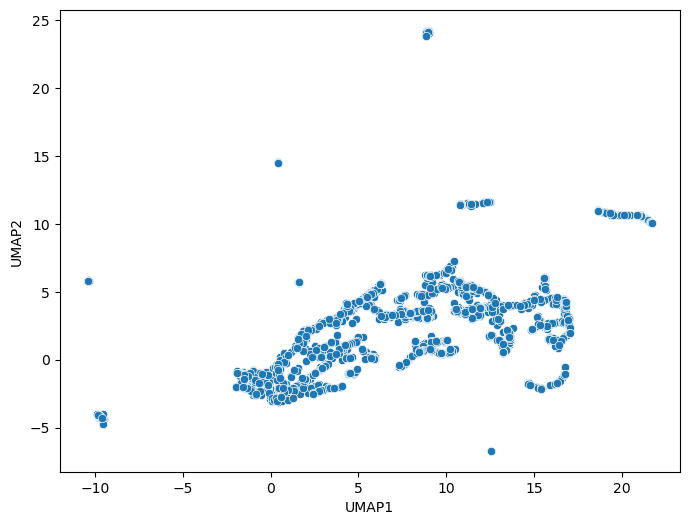

In [239]:
import umap.umap_ as umap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# pivot table creation, and feature engineering!!

scaler = StandardScaler()

#30 #20
svd = TruncatedSVD(n_components=20, random_state=56)
latent = svd.fit_transform(interaction_matrix)
scaler_latent = scaler.fit_transform(latent)

scaled_latent_df = pd.DataFrame(
    scaler_latent,
    index=interaction_matrix.index,
    columns=[f"latent_{i+1}" for i in range(scaler_latent.shape[1])]
)

reducer = umap.UMAP(random_state=26)
embedding = reducer.fit_transform(scaled_latent_df)

embeddings_df = pd.DataFrame(embedding, index= scaled_latent_df.index, columns=["UMAP1","UMAP2"])
#embeddings_with_clusters = pd.merge(cluster_labels, embeddings_df, left_index=True, right_index=True)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=embeddings_df,
    x="UMAP1",y="UMAP2",
    palette='mako'
)

'plt.figure(figsize=(8,6))\nsns.scatterplot(\n    data=pd.merge(cand_summ_22, embeddings_df, left_on=\'Cand_Id\', right_on=\'CAND_ID\'),\n    x="UMAP1",y="UMAP2",\n    palette = "tab10",\n    hue=\'Net_Contribution\'\n)'

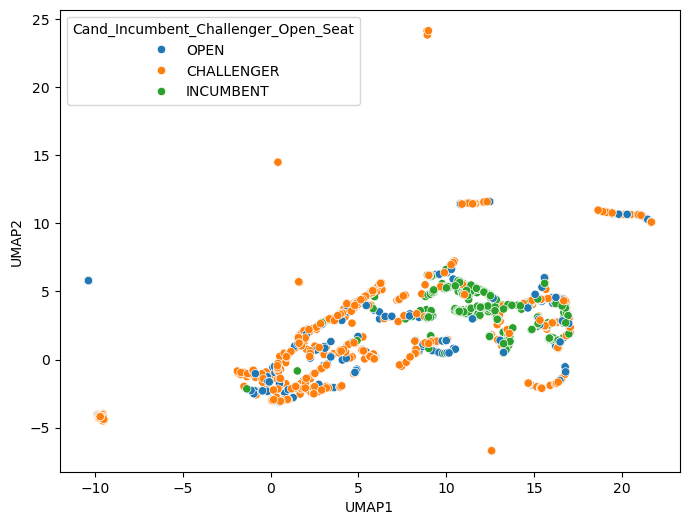

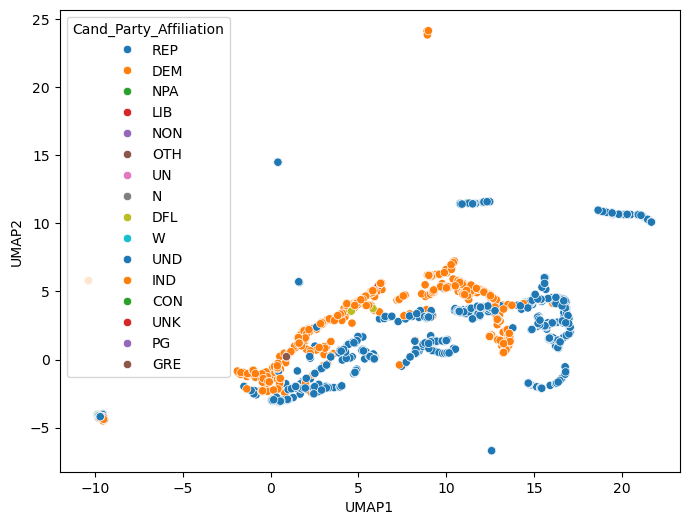

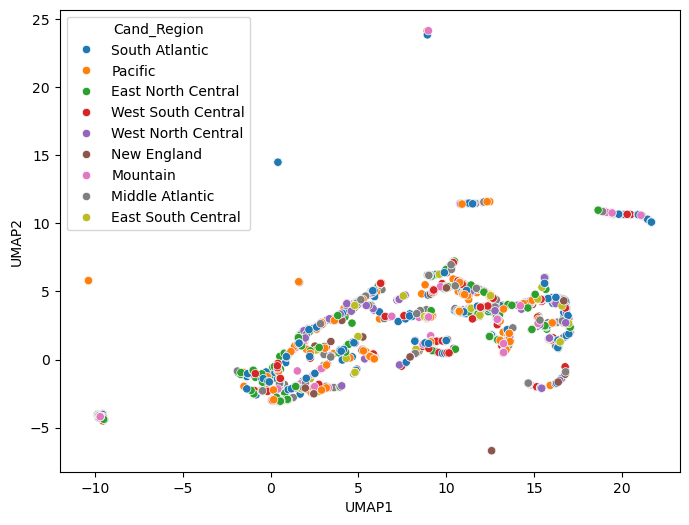

In [240]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pd.merge(cand_summ_22, embeddings_df, left_on='Cand_Id', right_on='CAND_ID'),
    x="UMAP1",y="UMAP2",
    palette = "tab10",
    hue='Cand_Incumbent_Challenger_Open_Seat'
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pd.merge(cand_summ_22, embeddings_df, left_on='Cand_Id', right_on='CAND_ID'),
    x="UMAP1",y="UMAP2",
    palette = "tab10",
    hue='Cand_Party_Affiliation'
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pd.merge(cand_summ_22, embeddings_df, left_on='Cand_Id', right_on='CAND_ID'),
    x="UMAP1",y="UMAP2",
    palette = "tab10",
    hue='Cand_Region'
)

"""plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pd.merge(cand_summ_22, embeddings_df, left_on='Cand_Id', right_on='CAND_ID'),
    x="UMAP1",y="UMAP2",
    palette = "tab10",
    hue='Net_Contribution'
)"""

In [241]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.cluster import HDBSCAN
from sklearn.cluster import AffinityPropagation
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

#dbscan = DBSCAN(eps= 0.1, min_samples = 10)
#clusters = dbscan.fit_predict(scaled_latent_df)

"""
for eps in [0.1, 0.3, 0.5, 0.7, 1.0]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    clusters = dbscan.fit_predict(scaled_latent_df)
    print(f"eps={eps}: {len(set(clusters)) - (1 if -1 in clusters else 0)} clusters, {sum(clusters == -1)} noise points")
"""

#hdbscan = HDBSCAN(min_cluster_size= 50, min_samples = 2)
#clusters = hdbscan.fit_predict(scaled_latent_df)

kmeans = KMeans(n_clusters=8, random_state=65)
clusters = kmeans.fit_predict(scaled_latent_df)

#ap = AffinityPropagation(damping = 0.9, preference = -50)
#clusters = ap.fit_predict(scaled_latent_df)

#gmm = GaussianMixture(n_components=8,covariance_type='full',random_state=56)
#clusters = gmm.fit_predict(scaled_latent_df)

"""results = []

for n in range(2,11):
    gmm = GaussianMixture(n_components=n,covariance_type='full',random_state=56)
    clusters = gmm.fit_predict(scaled_latent_df)

    score = silhouette_score(scaled_latent_df,clusters)
    results.append({'n_clusters': n, 'silhoutte_score':score})

silt_df = pd.DataFrame(results)"""

cluster_labels = pd.DataFrame(clusters, index=scaled_latent_df.index,columns=['cluster'])

C:\Users\wkmp2\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


C:\Users\wkmp2\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

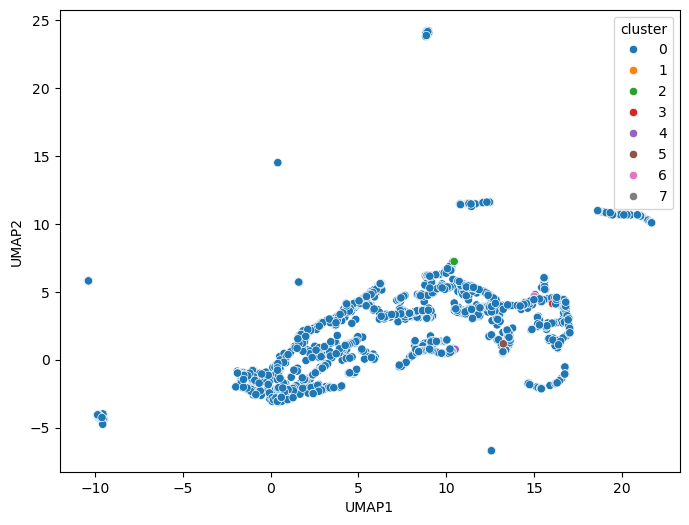

In [242]:
import umap.umap_ as umap
import seaborn as sns
import matplotlib.pyplot as plt

reducer = umap.UMAP(random_state=26)
embedding = reducer.fit_transform(scaled_latent_df)

embeddings_df = pd.DataFrame(embedding, index= scaled_latent_df.index, columns=["UMAP1","UMAP2"])
embeddings_with_clusters = pd.merge(cluster_labels, embeddings_df, left_index=True, right_index=True)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=embeddings_with_clusters,
    x="UMAP1",y="UMAP2",
    palette = "tab10",
    hue='cluster'
)

In [161]:
pd.merge(cand_summ_22, cluster_labels[cluster_labels['cluster'] == 3], left_on='Cand_Id', right_on='CAND_ID').sample(4)

,Link_Image,Cand_Name,Cand_Id,Cand_Office,Cand_Office_St,Cand_Office_Dist,Cand_Party_Affiliation,Cand_Incumbent_Challenger_Open_Seat,Total_Receipt,Total_Disbursement,...,Other_Committee_Refund,Total_Contribution_Refund,Other_Disbursements,Net_Contribution,Net_Operating_Expenditure,Cash_On_Hand_BOP,Debt_Owe_To_Committee,Coverage_Start_Date,Cand_Region,cluster
27,https://www.fec.gov/data/candidate/H2WA08182/?...,"LARKIN, MATT MR",H2WA08182,H,WA,8.0,REP,CHALLENGER,2810552.79,2806614.15,...,900.00,3250.00,0.00,1327868.21,2590289.48,0.0,0.0,01/01/2021,Pacific,3
12,https://www.fec.gov/data/candidate/H2AZ09191/?...,"COOPER, KELLY",H2AZ09191,H,AZ,4.0,REP,CHALLENGER,2342076.93,2283332.74,...,0.00,6406.06,500.00,780112.92,1435330.39,0.0,0.0,07/01/2021,Mountain,3
22,https://www.fec.gov/data/candidate/H2NY18087/?...,"SCHMITT, COLIN J",H2NY18087,H,NY,18.0,REP,CHALLENGER,2062676.07,2060312.62,...,2300.00,23828.31,5294.00,1835649.47,1996816.14,0.0,0.0,01/01/2021,Middle Atlantic,3
33,https://www.fec.gov/data/candidate/H2MI07123/?...,"BARRETT, THOMAS MORE",H2MI07123,H,MI,7.0,REP,CHALLENGER,2834473.95,2829219.04,...,420.26,45880.60,1509.79,2250039.80,2671977.82,0.0,0.0,07/01/2021,East North Central,3


In [163]:
interaction_matrix.loc['H2WA08182'].idxmax(axis=0)

'C00495028'

In [167]:
"""display(comm_summ_22[comm_summ_22['CMTE_ID']==interaction_matrix.loc['H2WA08182'].idxmax(axis=0)])
display(comm_summ_22[comm_summ_22['CMTE_ID']==interaction_matrix.loc['H2AZ09191'].idxmax(axis=0)])
display(comm_summ_22[comm_summ_22['CMTE_ID']==interaction_matrix.loc['H2NY18087'].idxmax(axis=0)])
display(comm_summ_22[comm_summ_22['CMTE_ID']==interaction_matrix.loc['H2MI07123'].idxmax(axis=0)])"""

for cand in ['H2WA08182', 'H2AZ09191', 'H2NY18087', 'H2MI07123']:
    top5 = interaction_matrix.loc[cand].nlargest(5).index
    display(comm_summ_22[comm_summ_22['CMTE_ID'].isin(top5)])

,Link_Image,CMTE_ID,CMTE_NM,CMTE_TP,CMTE_DSGN,CMTE_FILING_FREQ,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,...,ITEM_CONVN_EXP_DISB,ITEM_OTHER_DISB,SUBTTL_CONVN_EXP_DISB,TTL_EXP_SUBJECT_LIMITS,UNITEM_CONVN_EXP_DISB,UNITEM_OTHER_DISB,TTL_COMMUNICATION_COST,COH_BOY,COH_COY,ORG_TP
151,https://www.fec.gov/data/committee/C00568444/?...,C00568444,CENTER FORWARD COMMITTEE,O,B,Q,1214-A INGLESIDE AVE,SUITE 700,MCLEAN,VA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
247,https://www.fec.gov/data/committee/C00707844/?...,C00707844,EDF ACTION VOTES,O,U,M,PO BOX 15845,C/O MELE BRENGARTH & ASSOC,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
10904,https://www.fec.gov/data/committee/C00495028/?...,C00495028,HOUSE MAJORITY PAC,W,U,M,1032 15TH STREET NW,SUITE 247,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
12681,https://www.fec.gov/data/committee/C00818849/?...,C00818849,TOGETHER FOR PROGRESS,O,U,Q,PO BOX 21961,None,SEATTLE,WA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13869,https://www.fec.gov/data/committee/C00000935/?...,C00000935,DCCC,Y,U,M,"430 SOUTH CAPITOL STREET, SE",2ND FLOOR,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


,Link_Image,CMTE_ID,CMTE_NM,CMTE_TP,CMTE_DSGN,CMTE_FILING_FREQ,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,...,ITEM_CONVN_EXP_DISB,ITEM_OTHER_DISB,SUBTTL_CONVN_EXP_DISB,TTL_EXP_SUBJECT_LIMITS,UNITEM_CONVN_EXP_DISB,UNITEM_OTHER_DISB,TTL_COMMUNICATION_COST,COH_BOY,COH_COY,ORG_TP
8021,https://www.fec.gov/data/committee/C00698936/?...,C00698936,"WFW ACTION FUND, INC.",V,U,M,"700 12TH STREET, N.W",SUITE 700,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
10904,https://www.fec.gov/data/committee/C00495028/?...,C00495028,HOUSE MAJORITY PAC,W,U,M,1032 15TH STREET NW,SUITE 247,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13577,https://www.fec.gov/data/committee/C00523621/?...,C00523621,UNITED WE CAN,O,U,Q,"1800 MASSACHUSETTS AVE., NW",None,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13869,https://www.fec.gov/data/committee/C00000935/?...,C00000935,DCCC,Y,U,M,"430 SOUTH CAPITOL STREET, SE",2ND FLOOR,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13875,https://www.fec.gov/data/committee/C00075820/?...,C00075820,NRCC,Y,U,M,320 FIRST STREET SE,.,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


,Link_Image,CMTE_ID,CMTE_NM,CMTE_TP,CMTE_DSGN,CMTE_FILING_FREQ,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,...,ITEM_CONVN_EXP_DISB,ITEM_OTHER_DISB,SUBTTL_CONVN_EXP_DISB,TTL_EXP_SUBJECT_LIMITS,UNITEM_CONVN_EXP_DISB,UNITEM_OTHER_DISB,TTL_COMMUNICATION_COST,COH_BOY,COH_COY,ORG_TP
10326,https://www.fec.gov/data/committee/C00418897/?...,C00418897,VOTEVETS,W,U,M,PO BOX 11293,None,PORTLAND,OR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
10904,https://www.fec.gov/data/committee/C00495028/?...,C00495028,HOUSE MAJORITY PAC,W,U,M,1032 15TH STREET NW,SUITE 247,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
11035,https://www.fec.gov/data/committee/C00504530/?...,C00504530,CONGRESSIONAL LEADERSHIP FUND,W,U,Q,"1747 PENNSYLVANIA AVENUE, NW",5TH FLOOR,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13869,https://www.fec.gov/data/committee/C00000935/?...,C00000935,DCCC,Y,U,M,"430 SOUTH CAPITOL STREET, SE",2ND FLOOR,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13871,https://www.fec.gov/data/committee/C00011114/?...,C00011114,AMERICAN FEDERATION OF STATE COUNTY & MUNICIPA...,Q,B,M,1625 L STREET NW,None,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L


,Link_Image,CMTE_ID,CMTE_NM,CMTE_TP,CMTE_DSGN,CMTE_FILING_FREQ,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,...,ITEM_CONVN_EXP_DISB,ITEM_OTHER_DISB,SUBTTL_CONVN_EXP_DISB,TTL_EXP_SUBJECT_LIMITS,UNITEM_CONVN_EXP_DISB,UNITEM_OTHER_DISB,TTL_COMMUNICATION_COST,COH_BOY,COH_COY,ORG_TP
10326,https://www.fec.gov/data/committee/C00418897/?...,C00418897,VOTEVETS,W,U,M,PO BOX 11293,None,PORTLAND,OR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
10904,https://www.fec.gov/data/committee/C00495028/?...,C00495028,HOUSE MAJORITY PAC,W,U,M,1032 15TH STREET NW,SUITE 247,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
11436,https://www.fec.gov/data/committee/C00687103/?...,C00687103,"AMERICANS FOR PROSPERITY ACTION, INC. (AFP ACT...",O,U,M,2200 WILSON BLVD.,#102-177,ARLINGTON,VA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13869,https://www.fec.gov/data/committee/C00000935/?...,C00000935,DCCC,Y,U,M,"430 SOUTH CAPITOL STREET, SE",2ND FLOOR,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13875,https://www.fec.gov/data/committee/C00075820/?...,C00075820,NRCC,Y,U,M,320 FIRST STREET SE,.,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


<Axes: xlabel='Cand_Incumbent_Challenger_Open_Seat', ylabel='Count'>

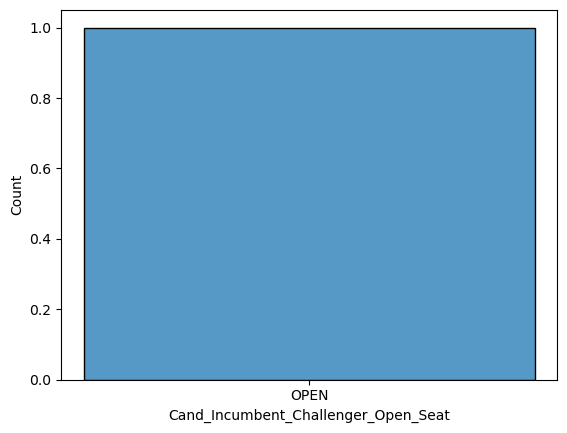

In [151]:
sns.histplot(pd.merge(cand_summ_22, cluster_labels[cluster_labels['cluster'] == 6], left_on='Cand_Id', right_on='CAND_ID'), x='Cand_Incumbent_Challenger_Open_Seat')

In [110]:
pd.merge(cand_summ_22, cluster_labels[cluster_labels['cluster'] == 1], left_on='Cand_Id', right_on='CAND_ID').columns

Index(['Link_Image', 'Cand_Name', 'Cand_Id', 'Cand_Office', 'Cand_Office_St',
       'Cand_Office_Dist', 'Cand_Party_Affiliation',
       'Cand_Incumbent_Challenger_Open_Seat', 'Total_Receipt',
       'Total_Disbursement', 'Cash_On_Hand_COP', 'Debt_Owed_By_Committee',
       'Coverage_End_Date', 'Cand_Street_1', 'Cand_Street_2', 'Cand_City',
       'Cand_State', 'Cand_Zip', 'Individual_Itemized_Contribution',
       'Individual_Unitemized_Contribution', 'Individual_Contribution',
       'Other_Committee_Contribution', 'Party_Committee_Contribution',
       'Cand_Contribution', 'Total_Contribution',
       'Transfer_From_Other_Auth_Committee', 'Cand_Loan', 'Other_Loan',
       'Total_Loan', 'Offsets_To_Operating_Expenditure',
       'Offsets_To_Fundraising', 'Offsets_To_Leagal_Accounting',
       'Other_Receipts', 'Operating_Expenditure',
       'Exempt_Legal_Accounting_Disbursement', 'Fundraising_Disbursement',
       'Transfer_To_Other_Auth_Committee', 'Cand_Loan_Repayment',
       'O

In [91]:
cluster_labels[cluster_labels['cluster'] == 1]

,cluster
CAND_ID,
H0AL02087,1
H0AL02202,1
H0CA18068,1
H0CA22110,1
H0CA28174,1
...,...
S8MN00586,1
S8MN00628,1
S8TX00285,1


In [5]:
comm_summ_22

,Link_Image,CMTE_ID,CMTE_NM,CMTE_TP,CMTE_DSGN,CMTE_FILING_FREQ,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,...,ITEM_CONVN_EXP_DISB,ITEM_OTHER_DISB,SUBTTL_CONVN_EXP_DISB,TTL_EXP_SUBJECT_LIMITS,UNITEM_CONVN_EXP_DISB,UNITEM_OTHER_DISB,TTL_COMMUNICATION_COST,COH_BOY,COH_COY,ORG_TP
0,https://www.fec.gov/data/committee/C00810655/?...,C00810655,LOUISIANA HOME BUILDERS ASSOCIATION POLITICAL ...,N,U,Q,5015 RIVER ROAD,None,HARAHAN,LA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,T
1,https://www.fec.gov/data/committee/C00805309/?...,C00805309,SAVE GLENDORA SCHOOLS,N,U,Q,100 BARRANCA STREET,#742,WEST COVINA,CA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,https://www.fec.gov/data/committee/C00726828/?...,C00726828,HUDSON VICTORY FUND,N,J,Q,824 S. MILLEDGE AVE,SUITE 101,ATHENS,GA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,https://www.fec.gov/data/committee/C00727529/?...,C00727529,MRVAN FOR CONGRESS,H,P,Q,PO BOX 55,None,CROWN POINT,IN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,https://www.fec.gov/data/committee/C00727123/?...,C00727123,CHRIS SMITH VICTORY FUND,N,J,Q,146 PROSPECT AVE,None,TRENTON,NJ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13971,https://www.fec.gov/data/committee/C00464149/?...,C00464149,MO BROOKS FOR SENATE,S,P,Q,7610 FOXFIRE DR.,None,HUNTSVILLE,AL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13972,https://www.fec.gov/data/committee/C00464602/?...,C00464602,VICKY HARTZLER FOR SENATE,S,P,Q,PO BOX 531,None,HARRISONVILLE,MO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13973,https://www.fec.gov/data/committee/C00464602/?...,C00464602,VICKY HARTZLER FOR SENATE,S,P,Q,PO BOX 531,None,HARRISONVILLE,MO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13974,https://www.fec.gov/data/committee/C00464149/?...,C00464149,MO BROOKS FOR SENATE,S,P,Q,7610 FOXFIRE DR.,None,HUNTSVILLE,AL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [6]:
x = [1,2,3]
def f(y):
    y[0] = 3
    return y

print(x)
print(f(x))
print (x)

[1, 2, 3]
[3, 2, 3]
[3, 2, 3]


### Nearest (fake) Neighbors

In [66]:
cand_interaction_matrix = (
    cc_ie_22[cc_ie_22['support_oppose_flag']=='S'].pivot_table(
        index="CAND_ID",          # rows
        columns="CMTE_ID",        # columns
        values="TRANSACTION_AMT", # cell values
        aggfunc="sum",            # sum of transactions
        fill_value=0              # replace NaNs with 0
    )
)

candidate_totals = cand_interaction_matrix.sum(axis=1)
candidate_totals = candidate_totals.replace(0, 1)
cand_interaction_matrix_scaled = cand_interaction_matrix.div(candidate_totals, axis=0)

In [67]:
comm_interaction_matrix = (
    cc_ie_22[cc_ie_22['support_oppose_flag']=='S'].pivot_table(
        index="CMTE_ID",          # rows
        columns="CAND_ID",        # columns
        values="TRANSACTION_AMT", # cell values
        aggfunc="sum",            # sum of transactions
        fill_value=0              # replace NaNs with 0
    )
)

committee_totals = comm_interaction_matrix.sum(axis=1)
committee_totals = committee_totals.replace(0, 1)
comm_interaction_matrix_scaled = comm_interaction_matrix.div(committee_totals, axis=0)

In [116]:
cand_interaction_matrix.loc['H2CO08079']['C00000935']

np.float64(0.0)

In [69]:
import umap.umap_ as umap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# pivot table creation, and feature engineering!!

scaler = StandardScaler()

#30 #20
svd = TruncatedSVD(n_components=15, random_state=56)
latent = svd.fit_transform(cand_interaction_matrix_scaled)
scaler_latent = scaler.fit_transform(latent)

cand_scaled_latent = pd.DataFrame(
    scaler_latent,
    index=cand_interaction_matrix_scaled.index,
    columns=[f"latent_{i+1}" for i in range(scaler_latent.shape[1])]
)

latent = svd.fit_transform(comm_interaction_matrix_scaled)
scaler_latent = scaler.fit_transform(latent)

comm_scaled_latent = pd.DataFrame(
    scaler_latent,
    index=comm_interaction_matrix_scaled.index,
    columns=[f"latent_{i+1}" for i in range(scaler_latent.shape[1])]
)

In [70]:
cand_scaled_latent

,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15
CAND_ID,,,,,,,,,,,,,,,
H0AL01055,0.022317,-0.021761,-0.018250,-0.008066,0.025697,0.049145,0.009563,-0.021962,-0.075845,0.018873,0.017079,-0.038976,-0.066699,-0.051877,-0.069722
H0AL02087,0.022367,-0.021761,-0.018597,-0.008681,0.020962,0.046690,0.014879,-0.021965,-0.066112,0.020880,0.005632,-0.024724,-0.057063,-0.052419,-0.069581
H0AL02202,0.022367,-0.021761,-0.018597,-0.008681,0.020962,0.046690,0.014879,-0.021965,-0.066112,0.020880,0.005632,-0.024724,-0.057063,-0.052418,-0.069581
H0AL05163,0.022367,-0.021761,-0.018606,-0.008797,0.020962,0.039219,0.014877,-0.021965,-0.093001,0.020893,0.021767,-0.040599,-0.056522,-0.052444,-0.069717
H0AL07086,0.022367,-0.021761,-0.018597,-0.008678,0.021981,0.046869,0.012311,-0.018092,-0.066133,0.015116,0.007363,-0.030738,-0.045464,-0.049015,-0.069756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S8TX00285,0.022367,-0.021761,-0.018597,-0.008681,0.020962,0.046690,0.014880,-0.021964,-0.066112,0.020880,0.005634,-0.024733,-0.057043,-0.052363,-0.069582
S8UT00176,0.019602,-0.021761,0.000357,0.024828,0.018723,0.176670,0.009436,-0.021966,-0.429601,0.020865,0.228109,-0.210550,-0.141236,-0.051986,-0.070637
S8WA00194,0.022367,-0.021761,-0.018597,-0.008681,0.020962,0.046691,0.014895,-0.021962,-0.066152,0.020876,0.005731,-0.024947,-0.056784,-0.052154,-0.069553


In [76]:
cand_summ_22.columns.str.contains('MACE')

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])

In [119]:
comm_cand_totals = cc_ie_22[cc_ie_22['support_oppose_flag']=='S'].groupby(['CMTE_ID','CAND_ID'])['TRANSACTION_AMT'].sum().reset_index().sort_values('TRANSACTION_AMT', ascending=False)

In [245]:
cand_summ_22.columns

Index(['Link_Image', 'Cand_Name', 'Cand_Id', 'Cand_Office', 'Cand_Office_St',
       'Cand_Office_Dist', 'Cand_Party_Affiliation',
       'Cand_Incumbent_Challenger_Open_Seat', 'Total_Receipt',
       'Total_Disbursement', 'Cash_On_Hand_COP', 'Debt_Owed_By_Committee',
       'Coverage_End_Date', 'Cand_Street_1', 'Cand_Street_2', 'Cand_City',
       'Cand_State', 'Cand_Zip', 'Individual_Itemized_Contribution',
       'Individual_Unitemized_Contribution', 'Individual_Contribution',
       'Other_Committee_Contribution', 'Party_Committee_Contribution',
       'Cand_Contribution', 'Total_Contribution',
       'Transfer_From_Other_Auth_Committee', 'Cand_Loan', 'Other_Loan',
       'Total_Loan', 'Offsets_To_Operating_Expenditure',
       'Offsets_To_Fundraising', 'Offsets_To_Leagal_Accounting',
       'Other_Receipts', 'Operating_Expenditure',
       'Exempt_Legal_Accounting_Disbursement', 'Fundraising_Disbursement',
       'Transfer_To_Other_Auth_Committee', 'Cand_Loan_Repayment',
       'O

In [246]:
from sklearn.neighbors import NearestNeighbors

# X = your matrix (n_samples × n_features)
# point = a 1 × n_features vector

point = cand_scaled_latent.loc['H0SC01394']

knn = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn.fit(cand_scaled_latent)

distances, indices = knn.kneighbors([point])

n_indices = cand_scaled_latent.index[indices[0]]

print("Neighbor indices:", cand_scaled_latent.index[indices[0]])
print("Distances:", distances[0])

for i in n_indices:
    display(cand_summ_22[cand_summ_22['Cand_Id'] == i][['Cand_Name', 'Cand_Id', 'Cand_Office', 'Cand_Office_St',
       'Cand_Office_Dist', 'Cand_Party_Affiliation',
       'Cand_Incumbent_Challenger_Open_Seat']])

for i in n_indices:
    display(comm_cand_totals[comm_cand_totals['CAND_ID'] == i].head(5).merge(comm_summ_22[['CMTE_ID','CMTE_NM']], on='CMTE_ID'))


Neighbor indices: Index(['H0SC01394', 'S6IN00191', 'H2CO08079', 'H8OH01043', 'H2NV03161'], dtype='object', name='CAND_ID')
Distances: [0.         0.00577997 0.00588206 0.00596212 0.00620393]


C:\Users\wkmp2\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,Cand_Name,Cand_Id,Cand_Office,Cand_Office_St,Cand_Office_Dist,Cand_Party_Affiliation,Cand_Incumbent_Challenger_Open_Seat
2028,"MACE, NANCY",H0SC01394,H,SC,1.0,REP,INCUMBENT


,Cand_Name,Cand_Id,Cand_Office,Cand_Office_St,Cand_Office_Dist,Cand_Party_Affiliation,Cand_Incumbent_Challenger_Open_Seat
3637,"YOUNG, TODD CHRISTOPHER",S6IN00191,S,IN,0.0,REP,INCUMBENT


,Cand_Name,Cand_Id,Cand_Office,Cand_Office_St,Cand_Office_Dist,Cand_Party_Affiliation,Cand_Incumbent_Challenger_Open_Seat
2151,"KIRKMEYER, BARBARA",H2CO08079,H,CO,8.0,REP,OPEN


...

,CMTE_ID,CAND_ID,TRANSACTION_AMT,CMTE_NM
0,C00687103,H0SC01394,431851.0,"AMERICANS FOR PROSPERITY ACTION, INC. (AFP ACT..."
1,C00760124,H0SC01394,105000.0,NATIONAL VICTORY ACTION FUND
2,C00809830,H0SC01394,64500.0,YOUR LOWCOUNTRY NEIGHBORS
3,C90018227,H0SC01394,32408.0,ANIMAL WELLNESS ACTION
4,C00809749,H0SC01394,18700.0,CONSERVATIVE VALUES PAC


,CMTE_ID,CAND_ID,TRANSACTION_AMT,CMTE_NM
0,C00760124,S6IN00191,208333.0,NATIONAL VICTORY ACTION FUND
1,C00788596,S6IN00191,86757.0,LANKFORD YOUNG VICTORY COMMITTEE
2,C00760082,S6IN00191,52000.0,AMERICAN ENERGY ACTION FUND
3,C70002563,S6IN00191,35928.0,NATIONAL ASSOCIATION OF REALTORS
4,C00030718,S6IN00191,29865.0,NATIONAL ASSOCIATION OF REALTORS POLITICAL ACT...


,CMTE_ID,CAND_ID,TRANSACTION_AMT,CMTE_NM
0,C00687103,H2CO08079,855706.0,"AMERICANS FOR PROSPERITY ACTION, INC. (AFP ACT..."
1,C00582700,H2CO08079,223308.0,LET AMERICA WORK
2,C00075820,H2CO08079,108000.0,NRCC
3,C00824292,H2CO08079,51861.0,AMERICAN LEADERSHIP PAC
4,C00821975,H2CO08079,19099.0,ENERGIZE OUR FUTURE


,CMTE_ID,CAND_ID,TRANSACTION_AMT,CMTE_NM
0,C00687103,H8OH01043,688318.0,"AMERICANS FOR PROSPERITY ACTION, INC. (AFP ACT..."
1,C00075820,H8OH01043,108000.0,NRCC
2,C00485540,H8OH01043,10000.0,LEADERSHIP FOR AMERICA TODAY TOMORROW AND ALWA...
3,C00467431,H8OH01043,10000.0,THE EYE OF THE TIGER POLITICAL ACTION COMMITTEE
4,C00448373,H8OH01043,10000.0,HUCK PAC


,CMTE_ID,CAND_ID,TRANSACTION_AMT,CMTE_NM
0,C00787432,H2NV03161,1110695.0,ALL FOR OUR COUNTRY
1,C00562595,H2NV03161,1039275.0,MORNING IN AMERICA PAC
2,C00687103,H2NV03161,510811.0,"AMERICANS FOR PROSPERITY ACTION, INC. (AFP ACT..."
3,C00811166,H2NV03161,150000.0,THE SENTINEL ACTION FUND
4,C00075820,H2NV03161,108000.0,NRCC


In [88]:
cc_ie_22

,CMTE_ID,TRAN_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,...,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,CAND_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,support_oppose_flag,TRANSACTION_AMT_LOG
0,C00000059,19061997,N,M10,P2022,202210199537584857,24K,CCM,BOOZMAN FOR ARKANSAS,ROGERS,...,2022-09-21,5000.0,C00476317,S0AR00150,1644394,None,2022 US PRIMARY,4111520221629531979,S,8.517393
1,C00000059,19062003,A,M7,P2022,202207269525052740,24K,CCM,CLEAVER FOR CONGRESS,KANSAS CITY,...,2022-06-07,5000.0,C00395848,H4MO05234,1619615,None,2022 US PRIMARY,4073020221553612683,S,8.517393
2,C00000059,19062008,N,M10,G2021,202210199537584857,24K,CCM,DEBBIE DINGELL FOR CONGRESS,YPSILANTI,...,2022-09-21,2000.0,C00558213,H4MI12079,1644394,None,2022 US GENERAL,4111520221629531980,S,7.601402
3,C00000059,19062117,A,M7,P2022,202207269525052740,24K,CCM,GRAVES FOR CONGRESS,KANSAS CITY,...,2022-06-07,5000.0,C00359034,H0MO06073,1619615,None,None,4073020221553612684,S,8.517393
4,C00000059,19062120,A,M7,P2022,202207269525052740,24K,CCM,KANSANS FOR LATURNER,TOPEKA,...,2022-06-07,5000.0,C00718346,H0KS02188,1619615,None,None,4073020221553612685,S,8.517393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
740823,C90021981,F57.000001,N,YE,R2022,202301309575144448,24E,ORG,CHINA TRIBUNE,None,...,2022-11-23,600.0,S0GA00559,S0GA00559,1681650,None,None,4013120231721282024,S,6.398595
740824,C90021999,F57.000001,N,YE,G2022,202301319575247178,24E,ORG,NORTHERN LIBERTY PRESS,PHILADELPHIA,...,2022-10-09,290.0,S6PA00274,S6PA00274,1683337,None,None,4020220231721979298,S,5.673323
740825,C90021999,F57.000002,N,YE,G2022,202301319575247178,24E,IND,"BROWN, TIM",PHILADELPHIA,...,2022-10-09,26.0,S6PA00274,S6PA00274,1683337,None,None,4020220231721979299,S,3.295837
740826,C90021999,F57.000003,N,YE,G2022,202301319575247178,24E,IND,"BROWN, TIM",PHILADELPHIA,...,2022-10-09,79.0,S6PA00274,S6PA00274,1683337,None,None,4020220231721979300,S,4.382027


In [117]:
comm_cand_totals = cc_ie_22[cc_ie_22['support_oppose_flag']=='S'].groupby(['CMTE_ID','CAND_ID'])['TRANSACTION_AMT'].sum().reset_index()

In [97]:
comm_summ_22.columns

Index(['Link_Image', 'CMTE_ID', 'CMTE_NM', 'CMTE_TP', 'CMTE_DSGN',
       'CMTE_FILING_FREQ', 'CMTE_ST1', 'CMTE_ST2', 'CMTE_CITY', 'CMTE_ST',
       'CMTE_ZIP', 'TRES_NM', 'CAND_ID', 'FEC_ELECTION_YR', 'INDV_CONTB',
       'PTY_CMTE_CONTB', 'OTH_CMTE_CONTB', 'TTL_CONTB',
       'TRANF_FROM_OTHER_AUTH_CMTE', 'OFFSETS_TO_OP_EXP', 'OTHER_RECEIPTS',
       'TTL_RECEIPTS', 'TRANF_TO_OTHER_AUTH_CMTE', 'OTH_LOAN_REPYMTS',
       'INDV_REF', 'POL_PTY_CMTE_REF', 'TTL_CONTB_REF', 'OTHER_DISB',
       'TTL_DISB', 'NET_CONTB', 'NET_OP_EXP', 'COH_BOP', 'CVG_START_DT',
       'COH_COP', 'CVG_END_DT', 'DEBTS_OWED_BY_CMTE', 'DEBTS_OWED_TO_CMTE',
       'INDV_ITEM_CONTB', 'INDV_UNITEM_CONTB', 'OTH_LOANS',
       'TRANF_FROM_NONFED_ACCT', 'TRANF_FROM_NONFED_LEVIN', 'TTL_NONFED_TRANF',
       'LOAN_REPYMTS_RECEIVED', 'OFFSETS_TO_FNDRSG', 'OFFSETS_TO_LEGAL_ACCTG',
       'FED_CAND_CONTB_REF', 'TTL_FED_RECEIPTS', 'SHARED_FED_OP_EXP',
       'SHARED_NONFED_OP_EXP', 'OTHER_FED_OP_EXP', 'TTL_OP_EXP',
       '

In [112]:
comm_cand_totals[comm_cand_totals['CAND_ID'] == 'H2CO08079'].merge(comm_summ_22[['CMTE_ID','CMTE_NM']], on='CMTE_ID').sort_values('TRANSACTION_AMT', ascending=False)

,CMTE_ID,CAND_ID,TRANSACTION_AMT,CMTE_NM
0,C00000935,H2CO08079,2557214.0,DCCC
1,C00495028,H2CO08079,1223615.0,HOUSE MAJORITY PAC
2,C00687103,H2CO08079,855706.0,"AMERICANS FOR PROSPERITY ACTION, INC. (AFP ACT..."
3,C00582700,H2CO08079,223308.0,LET AMERICA WORK
4,C00365536,H2CO08079,160468.0,CHC BOLD PAC
...,...,...,...,...
142,C00784496,H2CO08079,500.0,"LEAGUE FOR SPORTSMEN, LAW ENFORCEMENT AND DEFE..."
143,C00431932,H2CO08079,500.0,OVINTIV USA INC. PAC
144,C00561217,H2CO08079,124.0,NATIONAL WATERMELON ASSOCIATION INC POLITICAL ...
145,C00760397,H2CO08079,0.0,NO NONSENSE PAC


In [113]:
cand_contrib = cc_ie_22[cc_ie_22['CAND_ID'] == 'H2CO08079'].merge(comm_summ_22[['CMTE_ID','CMTE_NM']], on='CMTE_ID')

In [115]:
cand_contrib[cand_contrib['CMTE_NM']=='DCCC']

,CMTE_ID,TRAN_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,...,TRANSACTION_AMT,OTHER_ID,CAND_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,support_oppose_flag,TRANSACTION_AMT_LOG,CMTE_NM
2,C00000935,SE-1046713,A,M10,G2022,202303219579537476,24A,ORG,AMPLIFY MEDIA LLC,FRANKLIN PARK,...,399900.0,H2CO08079,H2CO08079,1694686,None,DATE OF DISSEMINATION: 09/13/22,4032320231737591531,O,12.898972,DCCC
3,C00000935,SE-1046725,A,M10,G2022,202303219579537482,24A,ORG,PESCADOR PUBLIC STRATEGIES LLC LAURA VOLLUZ,SAN ANTONIO,...,17986.0,H2CO08079,H2CO08079,1694686,None,DATE OF DISSEMINATION: 09/13/22,4032320231737591543,O,9.797405,DCCC
4,C00000935,SE-1046730,A,M10,G2022,202303219579537484,24A,ORG,PESCADOR PUBLIC STRATEGIES LLC LAURA VOLLUZ,SAN ANTONIO,...,31000.0,H2CO08079,H2CO08079,1694686,None,DATE OF DISSEMINATION: 09/13/22,4032320231737591548,O,10.341775,DCCC
5,C00000935,SE-1046736,A,M10,G2022,202303219579537487,24A,ORG,"RISING TIDE INTERACTIVE, LLC",WASHINGTON,...,99969.0,H2CO08079,H2CO08079,1694686,None,DATE OF DISSEMINATION: 09/13/22,4032320231737591554,O,11.512625,DCCC
6,C00000935,SE-1046931,A,M10,G2022,202303219579537496,24A,ORG,"RISING TIDE INTERACTIVE, LLC",WASHINGTON,...,6000.0,H2CO08079,H2CO08079,1694686,None,DATE OF DISSEMINATION: 09/13/22,4032320231737591572,O,8.699681,DCCC
7,C00000935,SE-1046932,A,M10,G2022,202303219579537495,24A,ORG,SENA KOZAR STRATEGIES,WASHINGTON,...,15000.0,H2CO08079,H2CO08079,1694686,None,DATE OF DISSEMINATION: 09/13/22,4032320231737591570,O,9.615872,DCCC
8,C00000935,SE-1046935,A,M10,G2022,202303219579537499,24A,ORG,VISION STRATEGY AND INSIGHTS INC.,SHERMAN OAKS,...,21000.0,H2CO08079,H2CO08079,1694686,None,DATE OF DISSEMINATION: 09/13/22,4032320231737591577,O,9.952325,DCCC
9,C00000935,SE-1046936,A,M10,G2022,202303219579537499,24A,ORG,VISION STRATEGY AND INSIGHTS INC.,SHERMAN OAKS,...,5000.0,H2CO08079,H2CO08079,1694686,None,DATE OF DISSEMINATION: 09/13/22,4032320231737591578,O,8.517393,DCCC
10,C00000935,SE-1047019,A,M10,G2022,202303219579537503,24A,ORG,AMPLIFY MEDIA LLC,FRANKLIN PARK,...,399834.0,H2CO08079,H2CO08079,1694686,None,DATE OF DISSEMINATION: 09/20/22,4032320231737591585,O,12.898807,DCCC
11,C00000935,SE-1047049,A,M10,G2022,202303219579537519,24A,ORG,"RISING TIDE INTERACTIVE, LLC",WASHINGTON,...,99969.0,H2CO08079,H2CO08079,1694686,None,DATE OF DISSEMINATION: 09/20/22,4032320231737591617,O,11.512625,DCCC
